# News trading model

Load the complete `public.article_insights` table from the local PostgreSQL database.

# 0. Environment Setup

In [1]:
%pip install pandas sqlalchemy "psycopg[binary]" torch transformers torcha
%pip install -q peft accelerate datasets
%pip install -U "torchao>=0.16.0"

import torch
from types import SimpleNamespace

###############################################################
## Data Preparation
################################################################

# If set to true, the train/validation/test split will be fixed and not random. This is useful for reproducibility.
FIXED_SPLIT = True

# Remove tickers from article insights
#   none - do not remove tickers
#   primary - remove only primary ticker
#   all - remove all tickers
REMOVE_TICKERS = "none"  # Options: "none", "primary", "all"

# Map of the sentiment
SENTIMENT_MAP = {
    1: "Strongly negative",
    2: "Negative",
    3: "Neutral",
    4: "Positive",
    5: "Strongly positive",
}
###############################################################
## Data Features
################################################################

# The column which contains the text that is the input for the model for
# predicting / extracting the sentiment
TEXT_COLUMN = "consolidated_insights"

# The column that contains the coded sentiment stemming from the text,
# used for training purposes only.
# 0=Unknown, 1=Strongly negative, 2=negative, 3=neutral, 4=positive, 5=Strongly positive
SENTIMENT_COLUMN = "sentiment"

# The column which is used to separate training, test and validation sets.
# The values in this column must be one of "training", "validation" or "test".
# Used only if FIXED_SPLIT is True. If FIXED_SPLIT is False, this column is ignored and the split is random.
SPLIT_COLUMN = "model_set"

# Column we want to predict: primary ticker price at +90 minutes ÷ price at article time − 1
TARGET_COLUMN = "gain_90m_after_article_first"

# The columns to be used as feature for model training. These columns must be present in the articles dataframe.
FEATURE_COLUMNS = [
    # Publishing outlet — some sources may be more market-moving than others
    "publisher",

    # --- Market state up to and including T (all safe: computed using only data at/before article time) ---

    # VIXY price at T vs... (volatility level at article time)
    "vix_at_article_time",

    # Target ticker's own price move from 09:30 open up to T (pre-article momentum)
    "intraday_gain_till_article_first",

    # AI-sector ETF (AIQ) move from open up to T (sector-wide)
    "aiq_ai_etf_intraday_gain_till_article",

    # --- Market state up to T-30 (pre-news baseline, for isolating the news effect) ---

    # Target ticker at T-30 vs 09:30 open
    "intraday_gain_till_30m_before_article_first",

    # AIQ at T-30 vs its open (sector control, pre-news)
    "aiq_ai_etf_intraday_gain_till_30m_before_article",

    # VIXY at T-30 vs its open (volatility control, pre-news)
    "vix_intraday_gain_till_30m_before_article_first",

    # T-30 -> T: price drift already underway right before pu
    # (safe: ends at T, does not touch the T+90 target window)
    "intraday_gain_30m_before_till_article_first",
]

assert TARGET_COLUMN not in FEATURE_COLUMNS, (
    f"Target column {TARGET_COLUMN!r} must not appear in FEATURE_COLUMNS."
)

# Map for displaying human-friendly titles
FEATURE_NAME_MAP = {
    "vix_at_article_time": "Vix",
    "intraday_gain_till_article_first": "Stock (Intraday Gain till Article)",
    "aiq_ai_etf_intraday_gain_till_article": "AI Index (Intraday Gain till Article)",
    # Add other mappings if desired, otherwise original column names will be used
}

################################################################
# Find the best device available: CUDA, MPS (Apple Silicon), or CPU
################################################################
DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
if torch.backends.mps.is_available():
    DEVICE = "mps"
device = torch.device(DEVICE)
print(f"Using device: {device}")


#################################################################
## model-specific hyperparameters
#################################################################

ENC_NN_SEPARATE = SimpleNamespace(
  MAX_LENGTH = 256,
  MODEL_NAME = "distilbert-base-uncased", # base model to use for tokenization & encoder
  TOKENIZATION_BATCH_SIZE = 128,
  ENCODER_TRAIN_BATCH_SIZE = 16,
  ENCODER_TRAIN_LEARNING_RATE = 1e-5,
  ENCODER_TRAIN_WEIGHT_DECAY = 0.01,
  ENCODER_TRAIN_EPOCHS = 10,
  FUSION_TRAIN_LEARNING_RATE = 1e-4,
  FUSION_TRAIN_WEIGHT_DECAY = 0.01,
  FUSION_TRAIN_BATCH_SIZE = 64,
  FUSION_TRAIN_EPOCHS = 100,
)

ENC_NN_COMBINED = SimpleNamespace(
  MAX_LENGTH = 256,
  MODEL_NAME = "distilbert-base-uncased",
  TRAIN_EPOCHS = 10,
  TRAIN_LEARNING_RATE = 1e-4,
  TRAIN_WEIGHT_DECAY = 0.01,
)

# TODO: Add more model (perhaps more modern ones?)
JSON_LLM_MODELS = {
    1: "Qwen/Qwen2.5-0.5B-Instruct",
    2: "HuggingFaceTB/SmolLM2-360M-Instruct",
    3: "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
}

JSON_LLM_CONFIG = SimpleNamespace(
  MODEL_CHOICE = 3, # refer to JSON_LLM_MODELS dictionary for available options
  MAX_LENGTH = 512,
  LLM_OUTPUT_DIR = "./news_lora_model",
  TRAIN_LEARNING_RATE = 1e-4,
  TRAIN_EPOCHS = 10,
  TRAIN_WEIGHTS_DECAY = 0.01,
  LORA_ALPHA = 16,
  LORA_DROPOUT = 0.1,
)



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 24.6 MB/s eta 0:00:00
  Created wheel for torcha: filename=torcha-0.1-py3-none-any.whl size=3346 sha256=29f9f36955239dd4586c07b7492248c9f06b283869bd7bf5ff50e24455e4b01c
  Stored in directory: /root/.cache/pip/wheels/e0/fa/b2/0c5128eebbb6617ef597e57f8f3aa6016c19822e62bd5d6e38
Successfully built torcha
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 44.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
Using device: cuda


# 1. Data Preparation

## 1a. Read data from database

### From local Postgres

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

DATABASE_URL = (
    "postgresql+psycopg://nivnoach@localhost:5432/news_trading_window"
)

engine = create_engine(DATABASE_URL)
with engine.connect() as connection:
    connection.execute(text("SELECT 1"))
print("Connected to PostgreSQL")

articles = pd.read_sql(
    "SELECT * FROM public.articles",
    con=engine,
)
articles.head()

print(f"Rows: {len(articles):,}")
print(f"Columns: {articles.shape[1]:,}")
articles.info()

OperationalError: (psycopg.OperationalError) connection failed: connection to server at "127.0.0.1", port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
Multiple connection attempts failed. All failures were:
- host: 'localhost', port: 5432, hostaddr: '::1': connection failed: connection to server at "::1", port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
- host: 'localhost', port: 5432, hostaddr: '127.0.0.1': connection failed: connection to server at "127.0.0.1", port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
(Background on this error at: https://sqlalche.me/e/20/e3q8)

### From Google Drive (CSV format)

In [10]:
import gdown
import pandas as pd

FILE_ID = '1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5'
URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
OUTPUT = 'articles.csv'

print("[1/2] Downloading the .csv file")
gdown.download(URL, OUTPUT, quiet=False)

print("[2/2] Reading the CSV file")
articles = pd.read_csv(OUTPUT)

print("Done")

[1/2] Downloading the .csv file


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5
From (redirected): https://drive.google.com/uc?export=download&id=1dNrRcWYmYFzopaHRkd9WQ_S0ZrFUt-k5&confirm=t&uuid=a8e76701-cde2-4c4d-9149-42e0b6e27ce0
To: /content/articles.csv
100%|██████████| 2.63G/2.63G [00:21<00:00, 124MB/s]


[2/2] Reading the CSV file
Done


## 1b. Prepare data (cleanup & split)

In [ ]:

def anonymize_tickers(insights, tickers):
    """
    Anonymize tickers in the insights text by replacing them with placeholders.
    The primary ticker is replaced with "TICKER1", the second with "TICKER2", etc.
    """
    if not tickers:
        return insights

    # Create a mapping of tickers to anonymized placeholders
    ticker_mapping = {ticker: f"TICKER{i+1}" for i, ticker in enumerate(tickers)}

    # Replace each ticker in the insights text with its corresponding placeholder
    for ticker, placeholder in ticker_mapping.items():
        insights = insights.replace(ticker, placeholder)

    return insights

required_columns = set(FEATURE_COLUMNS)
missing_columns = required_columns - set(articles.columns)

if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")
X = articles.drop(columns=[TARGET_COLUMN])
Y = articles[TARGET_COLUMN]

# Remove tickers from the consolidated_insights column based on the REMOVE_TICKERS setting
if REMOVE_TICKERS == "none":
    pass
elif REMOVE_TICKERS == "primary":
    X["consolidated_insights"] = X.apply(
        lambda row: anonymize_tickers(
            row["consolidated_insights"],
            [row["primary_ticker"]],
        )
        if pd.notna(row["consolidated_insights"]) and pd.notna(row["primary_ticker"])
        else row["consolidated_insights"],
        axis=1,
    )
elif REMOVE_TICKERS == "all":
    X["consolidated_insights"] = X.apply(
        lambda row: anonymize_tickers(
            row["consolidated_insights"],
            row["tickers"].split(",") if pd.notna(row["tickers"]) else [],
        )
        if pd.notna(row["consolidated_insights"]) and pd.notna(row["primary_ticker"])
        else row["consolidated_insights"],
        axis=1,
    )
else:
    raise ValueError(f"Invalid value for REMOVE_TICKERS: {REMOVE_TICKERS}")

# Split the dataset into training, validation, and test sets
if FIXED_SPLIT:
    train_mask = articles[SPLIT_COLUMN].eq("training")
    val_mask = articles[SPLIT_COLUMN].eq("validation")
    test_mask = articles[SPLIT_COLUMN].eq("test")
else:
    shuffled_indices = articles.sample(
        frac=1,
        random_state=42,
    ).index

    test_size = int(len(articles) * 0.15)
    val_size = int(len(articles) * 0.15)

    test_indices = shuffled_indices[:test_size]
    val_indices = shuffled_indices[test_size:test_size + val_size]
    train_indices = shuffled_indices[test_size + val_size:]

    train_mask = articles.index.isin(train_indices)
    val_mask = articles.index.isin(val_indices)
    test_mask = articles.index.isin(test_indices)

X_train, Y_train = X.loc[train_mask], Y.loc[train_mask]
X_val, Y_val = X.loc[val_mask], Y.loc[val_mask]
X_test, Y_test = X.loc[test_mask], Y.loc[test_mask]

print(f"Used {FIXED_SPLIT and 'FIXED, reproducible' or 'RANDOM, not reproducible'} split")
print(f"Train:      X={X_train.shape}, Y={Y_train.shape}")
print(f"Validation: X={X_val.shape}, Y={Y_val.shape}")
print(f"Test:       X={X_test.shape}, Y={Y_test.shape}")


Used FIXED, reproducible split
Train:      X=(3173, 46), Y=(3173,)
Validation: X=(1096, 46), Y=(1096,)
Test:       X=(1237, 46), Y=(1237,)


## 1c. Plot data statistics

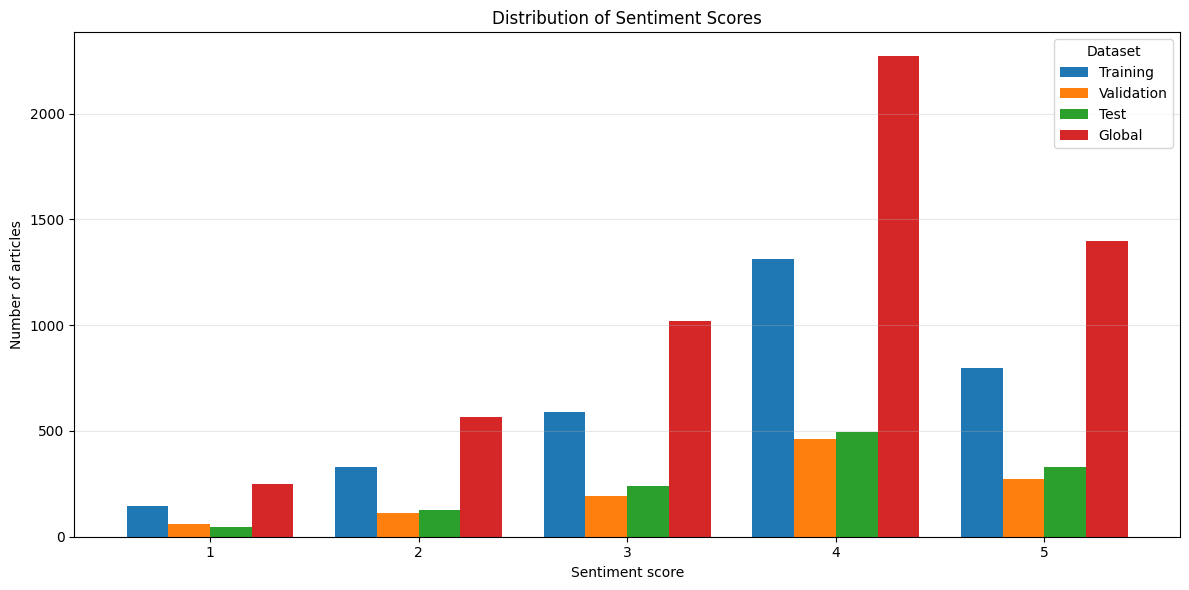

/tmp/ipykernel_110665/3684815618.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  all_dates = pd.to_datetime(articles["published_utc"].dropna())
/tmp/ipykernel_110665/3684815618.py:43: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  dates = pd.to_datetime(data["published_utc"].dropna())
/tmp/ipykernel_110665/3684815618.py:43: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=

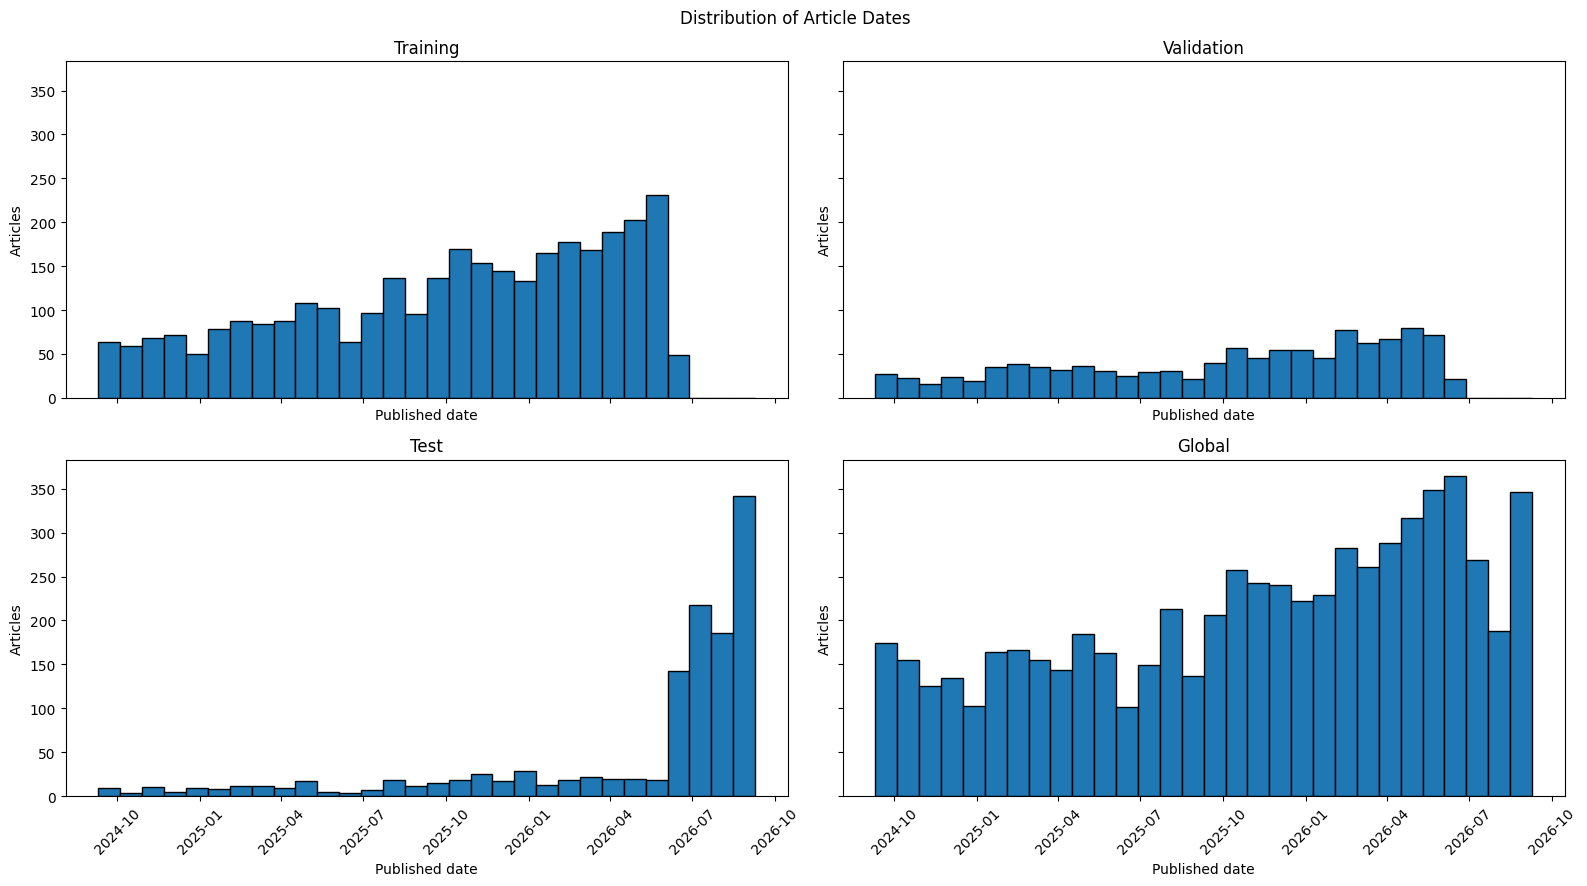

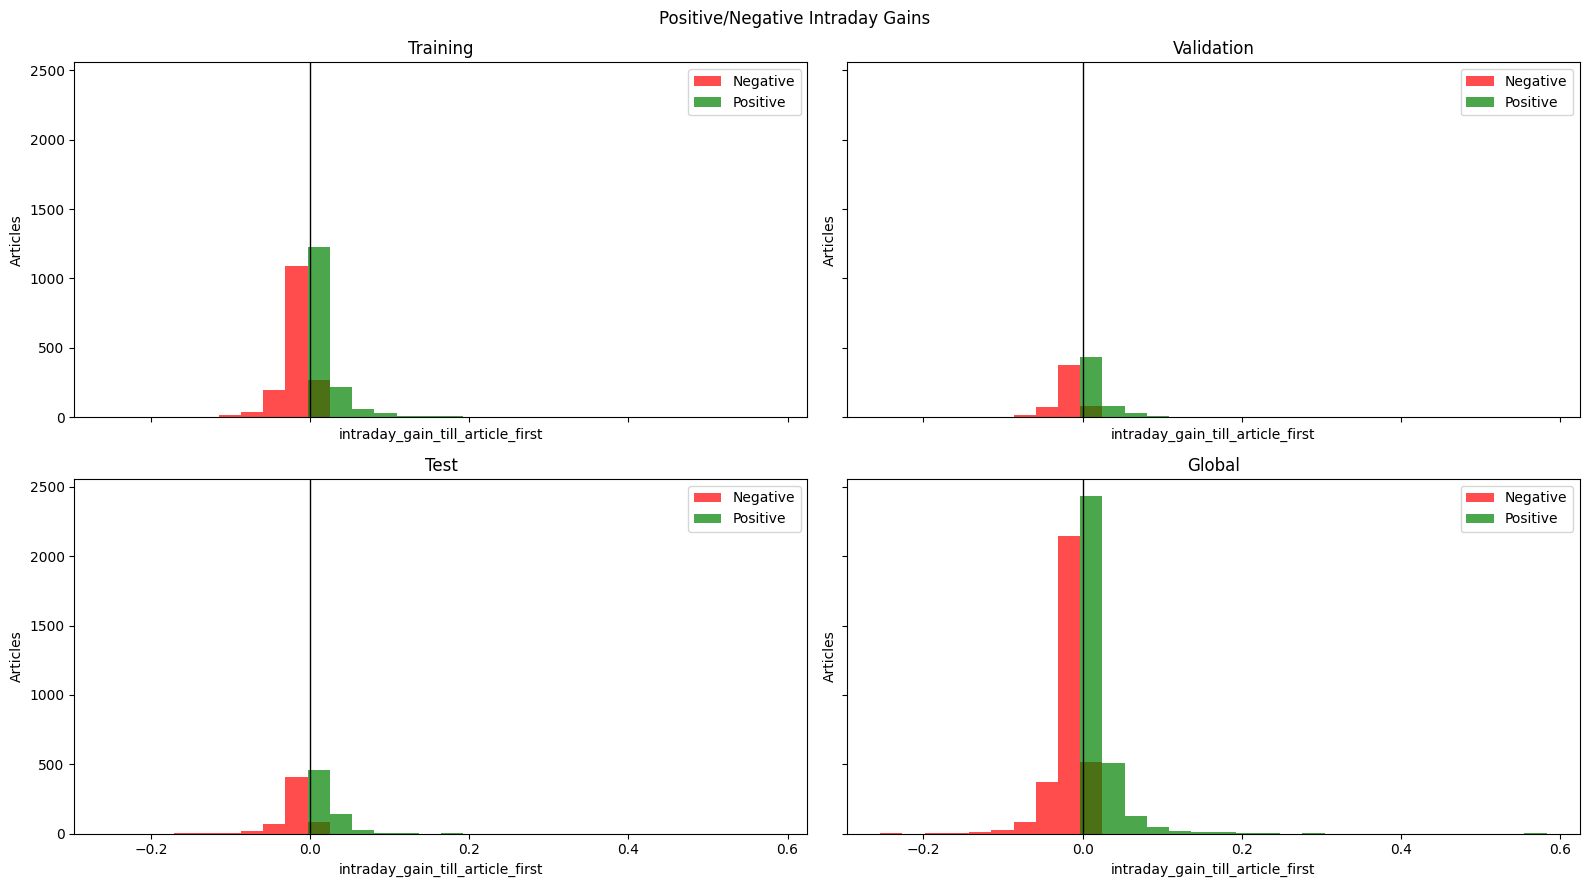

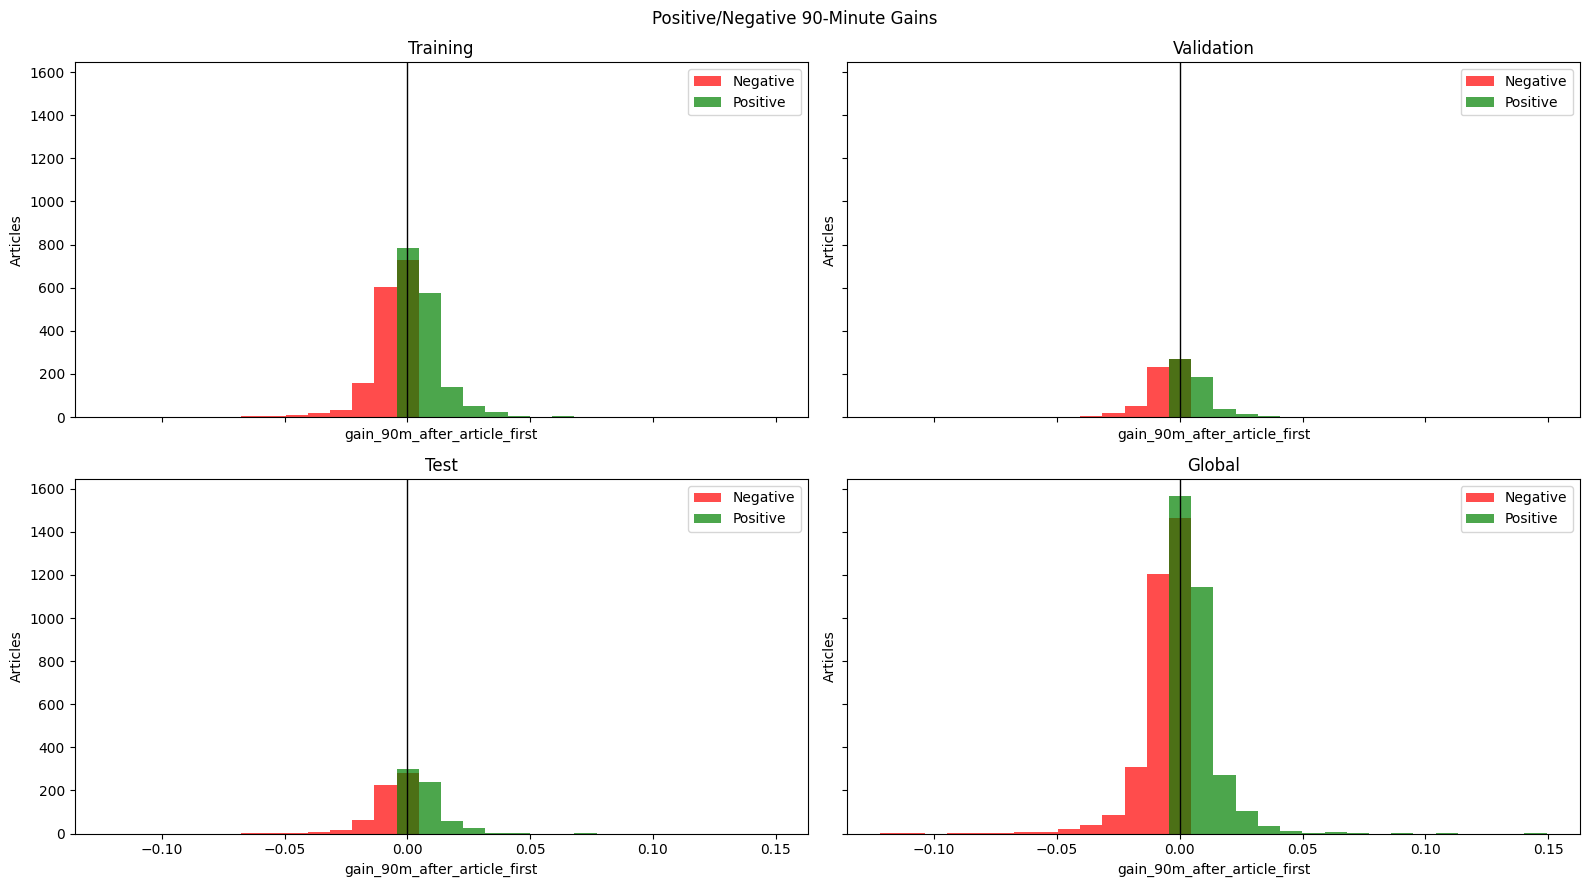

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sets = {
    "Training": articles.loc[train_mask],
    "Validation": articles.loc[val_mask],
    "Test": articles.loc[test_mask],
    "Global": articles,
}

# 0. Distribution of sentiment scores
sentiment_distribution = pd.DataFrame({
    name: data["sentiment"].value_counts().reindex(range(1, 6), fill_value=0)
    for name, data in sets.items()
})

ax = sentiment_distribution.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
)

ax.set_title("Distribution of Sentiment Scores")
ax.set_xlabel("Sentiment score")
ax.set_ylabel("Number of articles")
ax.set_xticklabels(range(1, 6), rotation=0)
ax.legend(title="Dataset")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 1. Distribution of article dates
all_dates = pd.to_datetime(articles["published_utc"].dropna())
date_bins = pd.date_range(
    all_dates.min().normalize(),
    all_dates.max().normalize() + pd.Timedelta(days=1),
    periods=31,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
for ax, (name, data) in zip(axes.flat, sets.items()):
    dates = pd.to_datetime(data["published_utc"].dropna())
    ax.hist(dates, bins=date_bins, edgecolor="black")
    ax.set_title(name)
    ax.set_xlabel("Published date")
    ax.set_ylabel("Articles")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Distribution of Article Dates")
plt.tight_layout()
plt.show()


def plot_gain_distribution(column, title):
    values = articles[column].dropna()
    gain_bins = np.linspace(values.min(), values.max(), 31)

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)

    for ax, (name, data) in zip(axes.flat, sets.items()):
        gains = data[column].dropna()
        positive = gains[gains > 0]
        negative = gains[gains < 0]

        ax.hist(negative, bins=gain_bins, alpha=0.7, label="Negative", color="red")
        ax.hist(positive, bins=gain_bins, alpha=0.7, label="Positive", color="green")
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(name)
        ax.set_xlabel(column)
        ax.set_ylabel("Articles")
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# 2. Intraday gains using the first-mentioned/first-listed ticker
plot_gain_distribution(
    "intraday_gain_till_article_first",
    "Positive/Negative Intraday Gains",
)

# 3. 90-minute gains using the first-mentioned/first-listed ticker
plot_gain_distribution(
    "gain_90m_after_article_first",
    "Positive/Negative 90-Minute Gains",
)



# 2. Training

In this section, we train 3 types of models for comparison:

(i) Encoder-NN, sparate - We separately train an Encoder to extract sentiment of an article, then we train a NN on the output (embedding vector) + market knowledge at the time of the article, to create a prediction of investment.

(ii) Encoder-NN, together - We train the same architecture as above, in a single training cycle.

(iii) JSON-LLM, LoRA - we provide all the inputs together as raw-json text, and fine-tune an LLM using LoRA.

## 2a. Encoder-NN, sparate

We separately train an Encoder to extract sentiment of an article, then we train a NN on the output (embedding vector) + market knowledge at the time of the article, to create a prediction of investment.

## 2a (i) Train encoder
The encode will recieve the article insights and will output its encoding.

In [ ]:
import copy
from types import SimpleNamespace
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer, AutoConfig, logging
import os

print("Preparing data...")

# Use the existing fixed train/validation/test split and only the text column.
def prepare_encoder_split(feature_frame, mask):
    indices = articles.index[mask]
    texts = feature_frame.loc[indices, TEXT_COLUMN].fillna("").astype(str)
    labels = articles.loc[indices, SENTIMENT_COLUMN]

    valid = labels.notna() & texts.str.strip().ne("")
    return (
        texts.loc[valid].tolist(),
        labels.loc[valid].astype("float32").to_numpy(),
    )


train_texts, train_labels = prepare_encoder_split(X, train_mask)
val_texts, val_labels = prepare_encoder_split(X, val_mask)
test_texts, test_labels = prepare_encoder_split(X, test_mask)


print("Tokenizing texts...")
tokenizer = AutoTokenizer.from_pretrained(ENC_NN_SEPARATE.MODEL_NAME)

def tokenize_texts(texts, batch_size=ENC_NN_SEPARATE.TOKENIZATION_BATCH_SIZE):
    input_ids = []
    attention_masks = []

    total_processed = 0
    for start in range(0, len(texts), batch_size):
        print(f"    > Tokenizing {start} - {start + batch_size}...", end="\r")
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=ENC_NN_SEPARATE.MAX_LENGTH,
            return_tensors="pt",
        )
        input_ids.append(encoded["input_ids"])
        attention_masks.append(encoded["attention_mask"])
        total_processed += len(batch)
    return torch.cat(input_ids), torch.cat(attention_masks)


print(f"    > Tokenizing {len(train_texts)} train")
train_ids, train_masks = tokenize_texts(train_texts)
print(f"      Done (train)                                         ")
print(f"    > Tokenizing {len(val_texts)} validation")
val_ids, val_masks = tokenize_texts(val_texts)
print(f"      Done (validation)                                    ")
print(f"    > Tokenizing {len(test_texts)} test")
test_ids, test_masks = tokenize_texts(test_texts)
print(f"      Done (test)                                          ")


class SentimentEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        print(f"    > Loading encoder model: {model_name}...")
        self.encoder = AutoModel.from_pretrained(
            model_name,
            config=AutoConfig.from_pretrained(model_name, proxied=True),
            local_files_only=False,
            force_download=True
        )
        print(f"      Done")

        print(f"    > Preparing regression head...")
        self.regression_head = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
        print(f"      Done")

    def forward(self, input_ids, attention_mask):
        output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (output.last_hidden_state * mask).sum(dim=1)
        pooled = pooled / mask.sum(dim=1).clamp(min=1e-9)

        return self.regression_head(pooled).squeeze(-1)


print("Preparing model...")
encoder_model = SentimentEncoder(ENC_NN_SEPARATE.MODEL_NAME).to(device)

print("Prepared dataloader...")
train_loader = DataLoader(
    TensorDataset(
        train_ids,
        train_masks,
        torch.tensor(train_labels),
    ),
    batch_size=ENC_NN_SEPARATE.ENCODER_TRAIN_BATCH_SIZE,
    shuffle=True,
)

print("Preparing optimizer...")
optimizer = torch.optim.AdamW(
    encoder_model.parameters(),
    lr=ENC_NN_SEPARATE.ENCODER_TRAIN_LEARNING_RATE,
    weight_decay=ENC_NN_SEPARATE.ENCODER_TRAIN_WEIGHT_DECAY,
)

loss_function = nn.MSELoss()
history = []
best_state = None
best_val_loss = float("inf")

print("Starting training...")
for epoch in range(1, ENC_NN_SEPARATE.ENCODER_TRAIN_EPOCHS + 1):
    encoder_model.train()
    train_losses = []

    for input_ids, attention_mask, labels in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        predictions = encoder_model(input_ids, attention_mask)
        loss = loss_function(predictions, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    encoder_model.eval()
    with torch.no_grad():
        val_predictions = encoder_model(
            val_ids.to(device),
            val_masks.to(device),
        )
        val_targets = torch.tensor(val_labels, device=device)
        val_loss = loss_function(val_predictions, val_targets).item()

    train_loss = float(np.mean(train_losses))
    val_mae = torch.mean(torch.abs(val_predictions - val_targets)).item()
    val_rmse = np.sqrt(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(encoder_model.state_dict())

    print(
        f"Epoch {epoch:2d} | "
        f"Train MSE={train_loss:.5f} | "
        f"Validation MAE={val_mae:.5f} | "
        f"Validation RMSE={val_rmse:.5f}"
    )

encoder_model.load_state_dict(best_state)
encoder_model.eval()

with torch.no_grad():
    test_predictions = encoder_model(
        test_ids.to(device),
        test_masks.to(device),
    )
    test_targets = torch.tensor(test_labels, device=device)
    test_errors = test_predictions - test_targets

test_mae = torch.mean(torch.abs(test_errors)).item()
test_rmse = torch.sqrt(torch.mean(test_errors ** 2)).item()

print(f"\nText-only test MAE:  {test_mae:.6f}")
print(f"Text-only test RMSE: {test_rmse:.6f}")

Preparing data...
Tokenizing texts...
    > Tokenizing 3173 train
      Done (train)                                         
    > Tokenizing 1096 validation
      Done (validation)                                    
    > Tokenizing 1237 test
      Done (test)                                          
Preparing model...
    > Loading encoder model: distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      Done
    > Preparing regression head...
      Done
Prepared dataloader...
Preparing optimizer...
Starting training...
Epoch  1 | Train MSE=2.96188 | Validation MAE=0.78450 | Validation RMSE=0.98335
Epoch  2 | Train MSE=0.65347 | Validation MAE=0.47826 | Validation RMSE=0.56504
Epoch  3 | Train MSE=0.45751 | Validation MAE=0.43803 | Validation RMSE=0.51351
Epoch  4 | Train MSE=0.35855 | Validation MAE=0.40178 | Validation RMSE=0.47668
Epoch  5 | Train MSE=0.31607 | Validation MAE=0.40557 | Validation RMSE=0.49859
Epoch  6 | Train MSE=0.27253 | Validation MAE=0.38140 | Validation RMSE=0.46639
Epoch  7 | Train MSE=0.23998 | Validation MAE=0.36790 | Validation RMSE=0.46160
Epoch  8 | Train MSE=0.21045 | Validation MAE=0.36269 | Validation RMSE=0.46126
Epoch  9 | Train MSE=0.20453 | Validation MAE=0.36079 | Validation RMSE=0.46102
Epoch 10 | Train MSE=0.19914 | Validation MAE=0.35736 | Validation RMSE=0.45447

Text-only test MAE:  0.375831
Text-only test RMSE: 0.484451


##  2a. (ii) Statistics of the Encoder training

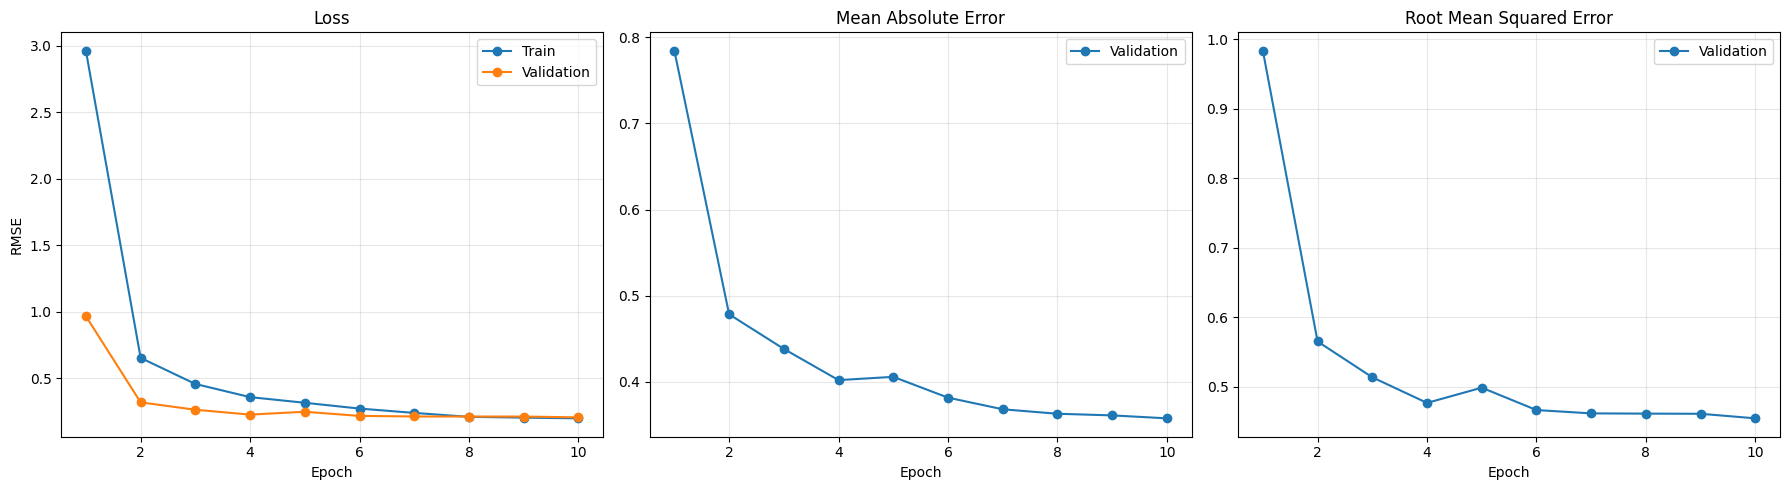

In [ ]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("loss", "Loss", "Loss"),
    ("mae", "MAE", "Mean Absolute Error"),
    ("rmse", "RMSE", "Root Mean Squared Error"),
]

# Plot loss for training set
axes[list(zip(*metrics))[0].index("loss")].plot(
    history_df["epoch"],
    history_df[f"train_loss"],
    marker="o",
    label="Train",
)
for metric, ylabel, title in metrics:
    axes[list(zip(*metrics))[0].index(metric)].plot(
        history_df["epoch"],
        history_df[f"val_{metric}"],
        marker="o",
        label="Validation",
    )
    axes[list(zip(*metrics))[0].index(metric)].set_title(title)
    axes[list(zip(*metrics))[0].index(metric)].set_xlabel("Epoch")
    axes[list(zip(*metrics))[0].setdefault(metric, 0) if False else 0].set_ylabel(ylabel)

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2a. (iii) Train the Neural Network ("Fusion Network")

In [ ]:
import copy
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# TEXT_COLUMN, encoder_model, tokenizer, DEVICE are available from previous cells

def clean_split(X_split, Y_split):
    """Cleans data by removing rows where the target is NaN."""
    valid_rows = Y_split.notna()
    X_clean = X_split.loc[valid_rows].copy()
    Y_clean = Y_split.loc[valid_rows].astype("float32")
    return X_clean, Y_clean

X_train_nn, Y_train_nn = clean_split(X_train, Y_train)
X_val_nn, Y_val_nn = clean_split(X_val, Y_val)
X_test_nn, Y_test_nn = clean_split(X_test, Y_test)

# This method will be used later for inferring text -> embedding
def infer_via_encoder(dataframe, batch_size=32):
    """Generates encoder output for the text column of a DataFrame."""
    texts = dataframe[TEXT_COLUMN].fillna("").astype(str).tolist()
    embeddings = []

    encoder_model.eval()

    for start in range(0, len(texts), batch_size):
        tokens = tokenizer(
            texts[start:start + batch_size],
            padding=True,
            truncation=True,
            max_length=ENC_NN_SEPARATE.MAX_LENGTH,
            return_tensors="pt",
        )
        tokens = {key: value.to(device) for key, value in tokens.items()}

        with torch.no_grad():
            output = encoder_model.encoder(**tokens)
            hidden_states = output.last_hidden_state
            mask = tokens["attention_mask"].unsqueeze(-1).float()

            pooled = (
                (hidden_states * mask).sum(dim=1)
                / mask.sum(dim=1).clamp(min=1e-9)
            )

        embeddings.append(pooled.cpu())

    return torch.cat(embeddings, dim=0)

print("Generating text embeddings...")
train_embeddings = infer_via_encoder(X_train_nn)
val_embeddings = infer_via_encoder(X_val_nn)
test_embeddings = infer_via_encoder(X_test_nn)
print(" > Done.")

# Use all configured non-text fields.
STRUCTURED_COLUMNS = [
    column for column in dict.fromkeys(FEATURE_COLUMNS)
    if column != TEXT_COLUMN
]

# Infer numeric and categorical fields.
NUMERIC_COLUMNS = [
    column
    for column in STRUCTURED_COLUMNS
    if pd.api.types.is_numeric_dtype(X_train_nn[column])
]

CATEGORICAL_COLUMNS = [
    column
    for column in STRUCTURED_COLUMNS
    if column not in NUMERIC_COLUMNS
]


# Numeric preprocessing.
def get_numeric_features(dataframe):
    """Extracts and returns numeric features from a DataFrame."""
    if not NUMERIC_COLUMNS:
        return torch.empty((len(dataframe), 0), dtype=torch.float32)

    values = dataframe[NUMERIC_COLUMNS].apply(
        pd.to_numeric,
        errors="coerce",
    )

    return values


train_numeric_df = get_numeric_features(X_train_nn)
val_numeric_df = get_numeric_features(X_val_nn)
test_numeric_df = get_numeric_features(X_test_nn)

if NUMERIC_COLUMNS:
    numeric_medians = train_numeric_df.median()

    train_numeric_df = train_numeric_df.fillna(numeric_medians)
    val_numeric_df = val_numeric_df.fillna(numeric_medians)
    test_numeric_df = test_numeric_df.fillna(numeric_medians)

    numeric_mean = torch.tensor(
        train_numeric_df.mean().to_numpy(),
        dtype=torch.float32,
    )
    numeric_std = torch.tensor(
        train_numeric_df.std().replace(0, 1).fillna(1).to_numpy(),
        dtype=torch.float32,
    )

    train_numeric = (
        torch.tensor(train_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std

    val_numeric = (
        torch.tensor(val_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std

    test_numeric = (
        torch.tensor(test_numeric_df.to_numpy(), dtype=torch.float32)
        - numeric_mean
    ) / numeric_std
else:
    train_numeric = torch.empty((len(X_train_nn), 0), dtype=torch.float32)
    val_numeric = torch.empty((len(X_val_nn), 0), dtype=torch.float32)
    test_numeric = torch.empty((len(X_test_nn), 0), dtype=torch.float32)


# Categorical preprocessing, fitted using the training split.
def get_categorical_features(dataframe, feature_columns=None):
    """Extracts and one-hot encodes categorical features from a DataFrame."""
    if not CATEGORICAL_COLUMNS:
        return torch.empty((len(dataframe), 0), dtype=torch.float32)

    values = dataframe[CATEGORICAL_COLUMNS].copy()

    for column in CATEGORICAL_COLUMNS:
        values[column] = values[column].fillna("__missing__").astype(str)

    encoded = pd.get_dummies(values)
    if feature_columns is not None:
        return encoded.reindex(columns=feature_columns, fill_value=0)
    return encoded


if CATEGORICAL_COLUMNS:
    train_categorical_df = get_categorical_features(X_train_nn)
    categorical_feature_columns = train_categorical_df.columns # Define here

    train_categorical = torch.tensor(
        train_categorical_df.to_numpy(dtype="float32")
    )
    val_categorical = torch.tensor(
        get_categorical_features(X_val_nn, categorical_feature_columns).to_numpy(dtype="float32")
    )
    test_categorical = torch.tensor(
        get_categorical_features(X_test_nn, categorical_feature_columns).to_numpy(dtype="float32")
    )
else:
    train_categorical = torch.empty((len(X_train_nn), 0))
    val_categorical = torch.empty((len(X_val_nn), 0))
    test_categorical = torch.empty((len(X_test_nn), 0))

print("Combining all features...")
train_features = torch.cat(
    [train_embeddings, train_numeric, train_categorical],
    dim=1,
)
val_features = torch.cat(
    [val_embeddings, val_numeric, val_categorical],
    dim=1,
)
test_features = torch.cat(
    [test_embeddings, test_numeric, test_categorical],
    dim=1,
)

train_targets = torch.tensor(Y_train_nn.to_numpy(), dtype=torch.float32)
val_targets = torch.tensor(Y_val_nn.to_numpy(), dtype=torch.float32)
test_targets = torch.tensor(Y_test_nn.to_numpy(), dtype=torch.float32)
print("Features and targets prepared.")

class FusionNetwork(nn.Module):
    """A simple neural network for combining features and predicting a target."""
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)


fusion_model = FusionNetwork(train_features.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(
    fusion_model.parameters(),
    lr=ENC_NN_SEPARATE.FUSION_TRAIN_LEARNING_RATE,
    weight_decay=ENC_NN_SEPARATE.FUSION_TRAIN_WEIGHT_DECAY,
)
loss_function = nn.MSELoss()

train_loader = DataLoader(
    TensorDataset(train_features, train_targets),
    batch_size=ENC_NN_SEPARATE.FUSION_TRAIN_BATCH_SIZE,
    shuffle=True,
)

best_state = None
best_val_loss = float("inf")
fusion_history = []

print("Starting Fusion Network training...")
for epoch in range(1, ENC_NN_SEPARATE.FUSION_TRAIN_EPOCHS + 1):
    fusion_model.train()
    train_losses = []

    for batch_features, batch_targets in train_loader:
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()
        predictions = fusion_model(batch_features)
        loss = loss_function(predictions, batch_targets)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    fusion_model.eval()
    with torch.no_grad():
        val_predictions = fusion_model(val_features.to(device))
        val_loss = torch.mean(
            (val_predictions - val_targets.to(device)) ** 2
        ).item()

    train_loss = float(np.mean(train_losses))
    val_mae = torch.mean(torch.abs(val_predictions - val_targets.to(device))).item()
    val_rmse = np.sqrt(val_loss)

    fusion_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(fusion_model.state_dict())

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train MSE={train_loss:.5f} | "
            f"Validation MAE={val_mae:.5f} | "
            f"Validation RMSE={val_rmse:.6f}"
        )


fusion_model.load_state_dict(best_state)
fusion_model.eval()

with torch.no_grad():
    test_predictions = fusion_model(test_features.to(device))
    test_errors = test_predictions - test_targets.to(device)

test_mae = torch.mean(torch.abs(test_errors)).item()
test_rmse = torch.sqrt(torch.mean(test_errors ** 2)).item()

print(f"\nTest MAE:  {test_mae:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")

Generating text embeddings...
 > Done.
Combining all features...
Features and targets prepared.
Starting Fusion Network training...
Epoch   1 | Train MSE=0.00220 | Validation MAE=0.00954 | Validation RMSE=0.013028
Epoch  10 | Train MSE=0.00031 | Validation MAE=0.01006 | Validation RMSE=0.012968
Epoch  20 | Train MSE=0.00027 | Validation MAE=0.00914 | Validation RMSE=0.012182
Epoch  30 | Train MSE=0.00021 | Validation MAE=0.00881 | Validation RMSE=0.011911
Epoch  40 | Train MSE=0.00019 | Validation MAE=0.00761 | Validation RMSE=0.011022
Epoch  50 | Train MSE=0.00017 | Validation MAE=0.00782 | Validation RMSE=0.011231
Epoch  60 | Train MSE=0.00015 | Validation MAE=0.00748 | Validation RMSE=0.010761
Epoch  70 | Train MSE=0.00014 | Validation MAE=0.00742 | Validation RMSE=0.010903
Epoch  80 | Train MSE=0.00013 | Validation MAE=0.00742 | Validation RMSE=0.010771
Epoch  90 | Train MSE=0.00012 | Validation MAE=0.00741 | Validation RMSE=0.010775
Epoch 100 | Train MSE=0.00011 | Validation MAE=0

In [ ]:
import pandas as pd
import torch
from torch import nn
import numpy as np

# Combine the two trained models to infer prediction on gain 90m after the article time
def predict_gain_90m_after_article(
    text,
    features_columns_values, # A dictionary containing the values for structured features
    fusion_model,
    numeric_mean, # torch.tensor (mean for normalization)
    numeric_std,  # torch.tensor (std for normalization)
    categorical_feature_columns, # pandas Index (columns for one-hot encoding)
    numeric_medians_series, # pandas Series (for filling NaNs in numeric features)
):
    """
    Predict gain_90m_after_article using text embeddings and structured features.

    Args:
        text (str): The article text for which to predict the gain.
        features_columns_values (dict): A dictionary containing the values for
                                        all structured FEATURE_COLUMNS.
        fusion_model (nn.Module): The trained FusionNetwork model.
        numeric_mean (torch.Tensor): Mean values for normalizing numeric features.
        numeric_std (torch.Tensor): Standard deviation values for normalizing numeric features.
        categorical_feature_columns (pd.Index): Column names for one-hot encoded categorical features (from training data).
        numeric_medians_series (pd.Series): Median values for numeric features (from training data, for NaN filling).

    Returns:
        float: The predicted gain_90m_after_article.
    """

    encoder_model.eval() # Corrected from model.eval()
    fusion_model.eval()

    # 1. Process text to get embeddings
    tokens = tokenizer(
        [str(text)], # Wrap text in a list to handle as a batch of 1
        padding=True,
        truncation=True,
        max_length=ENC_NN_SEPARATE.MAX_LENGTH,
        return_tensors="pt",
    )
    tokens = {key: value.to(DEVICE) for key, value in tokens.items()}

    with torch.no_grad():
        # Access the underlying encoder directly to get its output with last_hidden_state
        encoder_output = encoder_model.encoder(input_ids=tokens["input_ids"], attention_mask=tokens["attention_mask"])
        hidden_states = encoder_output.last_hidden_state
        mask = tokens["attention_mask"].unsqueeze(-1).float()

        embedding = (
            (hidden_states * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1e-9)
        ).to(device) # Ensure embedding is on the correct device

    # 2. Process structured features
    # Create a DataFrame from the input dict, ensuring all relevant columns are present
    features_df = pd.DataFrame([features_columns_values])

    # --- Numeric Features ---
    numeric_input_tensor = torch.empty((1, 0), dtype=torch.float32, device=DEVICE)
    if NUMERIC_COLUMNS:
        # Ensure all NUMERIC_COLUMNS are present in features_df before applying operations
        for col in NUMERIC_COLUMNS:
            if col not in features_df.columns:
                features_df[col] = np.nan # Add missing columns as NaN

        values = features_df[NUMERIC_COLUMNS].apply(pd.to_numeric, errors="coerce")
        # Fill NaNs using the pre-computed medians from training data
        values = values.fillna(numeric_medians_series[NUMERIC_COLUMNS])

        numeric_raw = torch.tensor(values.to_numpy(), dtype=torch.float32, device=DEVICE)
        numeric_input_tensor = (numeric_raw - numeric_mean.to(DEVICE)) / numeric_std.to(DEVICE)

    # --- Categorical Features ---
    categorical_input_tensor = torch.empty((1, 0), dtype=torch.float32, device=DEVICE)
    if CATEGORICAL_COLUMNS:
        # Ensure all CATEGORICAL_COLUMNS are present in features_df before applying operations
        for col in CATEGORICAL_COLUMNS:
            if col not in features_df.columns:
                features_df[col] = np.nan # Add missing columns as NaN

        values = features_df[CATEGORICAL_COLUMNS].copy()
        for col in CATEGORICAL_COLUMNS:
            values[col] = values[col].fillna("__missing__").astype(str)

        encoded = pd.get_dummies(values)
        encoded = encoded.reindex(columns=categorical_feature_columns, fill_value=0)
        categorical_input_tensor = torch.tensor(encoded.to_numpy(dtype="float32"), device=DEVICE)

    # 3. Combine features and predict
    combined_features = torch.cat(
        [embedding, numeric_input_tensor, categorical_input_tensor],
        dim=1,
    )

    with torch.no_grad():
        prediction = fusion_model(combined_features)

    return prediction.item()

# --- Prepare the necessary parameters from the training context (from cell 5dabfcfd) ---

# Re-calculate numeric_mean and numeric_std as Tensors, as they might not be globally persisted
if 'train_numeric_df' in globals() and not train_numeric_df.empty:
    _numeric_mean_tensor = torch.tensor(
        train_numeric_df[NUMERIC_COLUMNS].mean().to_numpy(),
        dtype=torch.float32,
    )
    _numeric_std_tensor = torch.tensor(
        train_numeric_df[NUMERIC_COLUMNS].std().replace(0, 1).fillna(1).to_numpy(),
        dtype=torch.float32,
    )
else:
    raise RuntimeError("train_numeric_df not found or empty. Cannot define numeric_mean and numeric_std for prediction.")

# Ensure categorical_feature_columns is available
if 'categorical_feature_columns' not in globals():
    raise RuntimeError("`categorical_feature_columns` is not defined in the global scope. Cannot make predictions.")

# Ensure numeric_medians is available
if 'numeric_medians' not in globals():
    raise RuntimeError("`numeric_medians` is not defined in the global scope. Cannot make predictions.")
_numeric_medians_series = numeric_medians # Alias for clarity


# --- Perform predictions on X_test ---
predictions = []

print("Starting predictions on test set...")
for idx, row in X_test.iterrows():
    current_features_values = {}
    for col in FEATURE_COLUMNS:
        if col != TEXT_COLUMN:
            current_features_values[col] = row[col]

    predictions.append(
        predict_gain_90m_after_article(
            text=row[TEXT_COLUMN],
            features_columns_values=current_features_values,
            fusion_model=fusion_model,
            numeric_mean=_numeric_mean_tensor,
            numeric_std=_numeric_std_tensor,
            categorical_feature_columns=categorical_feature_columns,
            numeric_medians_series=_numeric_medians_series,
        )
    )

predictions_table = X_test.copy()
predictions_table["prediction"] = predictions
predictions_table["Y_test"] = Y_test

print("Predictions complete.")
predictions_table

Starting predictions on test set...
Predictions complete.


,id,url,url_canonical,source_domain,publisher,tickers,published_utc,title,author,content,...,test_unseen,intraday_gain_till_30m_before_article_first,aiq_ai_etf_intraday_gain_till_30m_before_article,vix_intraday_gain_till_30m_before_article_first,article_in_first_market_30m,intraday_gain_30m_before_to_90m_after_article_first,intraday_gain_30m_before_till_article_first,sentiment,prediction,Y_test
31,23319,https://www.fool.com/coverage/better-buy/2026/...,https://www.fool.com/coverage/better-buy/2026/...,fool.com,The Motley Fool,"{AMZN,LUMN,T,TBB,TPA,TPC,VSAT}",2026-07-16 17:13:01+03,Lumen Technologies vs. Viasat: Which Data Netw...,Brendan Coffey,The digital world depends on physical infrastr...,...,t,-0.004822,-0.008479,0.008379,f,0.006342,0.001044,3.0,0.001410,0.005292
38,15769,https://www.fool.com/investing/2026/02/13/top-...,https://www.fool.com/investing/2026/02/13/top-...,fool.com,The Motley Fool,"{NVDA,STX}",2026-02-13 21:28:00+02,"Got $1,000? 2 Top Growth Stocks to Buy That Co...",Harsh Chauhan,Buying fast-growing companies and holding thei...,...,f,-0.018163,0.013875,-0.020459,f,-0.006850,-0.002010,5.0,-0.000210,-0.004850
52,18522,https://www.investing.com/analysis/claude-how-...,https://www.investing.com/analysis/claude-how-...,investing.com,Investing.com,"{MU,NVDA,WDC}",2026-04-16 18:36:00+03,"’Claude, How Can I Get 8.3% Dividends From AI?...",NaN,"We told you first: Picked by our AI yesterday,...",...,f,0.009193,0.000188,0.005646,f,-0.006449,0.000828,5.0,-0.001466,-0.007271
71,9691,https://www.benzinga.com/trading-ideas/small-c...,https://www.benzinga.com/trading-ideas/small-c...,benzinga.com,Benzinga,"{CRWD,INTC,NVDA}",2025-09-18 20:18:13+03,"Small Caps Rally, Intel Rockets On Best Day Ev...",Piero Cingari,"The Russell 2000, which tracks small caps, ral...",...,f,0.001963,0.004297,0.003143,f,-0.041687,-0.025309,5.0,-0.007828,-0.016803
81,585,https://www.fool.com/investing/2024/11/19/ever...,https://www.fool.com/investing/2024/11/19/ever...,fool.com,The Motley Fool,{NVDA},2024-11-19 16:41:00+02,Every Nvidia Investor Should Keep an Eye on Th...,Howard Smith,It's no secret that Nvidia (NVDA 0.84%) has su...,...,f,-0.002760,-0.000799,0.004221,t,0.022843,0.016959,4.0,-0.000303,0.005786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,25174,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{NOW},2026-07-24 18:47:00+03,Learning Tree International se convierte en so...,Learning Tree International; Inc,"HERNDON, Virginia, July 24, 2026 (GLOBE NEWSWI...",...,t,0.024968,-0.005763,-0.018510,f,0.001182,-0.002518,4.0,-0.001318,0.003710
6324,24029,https://www.fool.com/investing/2026/07/10/alph...,https://www.fool.com/investing/2026/07/10/alph...,fool.com,The Motley Fool,"{GOOG,GOOGL,GOOGM,GOOGN,PG,VZ}",2026-07-10 19:05:00+03,Alphabet Is the Dow's Newest Member. This One ...,Scott Levine,It's not often that components of the Dow Jone...,...,t,-0.008238,-0.002832,-0.009639,f,0.000312,0.001392,4.0,0.000114,-0.001078
6326,24031,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,"{GOOG,GOOGL,GOOGM,GOOGN}",2026-07-14 18:00:00+03,Revenium Completes SOC 2 Type II Compliance,Revenium,"HERNDON, Va., July 14, 2026 (GLOBE NEWSWIRE) -...",...,t,0.014448,-0.004931,0.000000,f,-0.002487,0.003815,5.0,0.001383,-0.006278
6327,24864,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{MSFT},2026-07-27 17:55:00+03,Security Risk Advisors Named a Finalist in CRN...,Security Risk Advisors,"PHILADELPHIA, July 27, 2026 (GLOBE NEWSWIRE) -...",...,t,0.001243,-0.017458,0.023844,f,0.000617,-0.002471,5.0,-0.014603,0.003095


/tmp/ipykernel_110665/3250824216.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


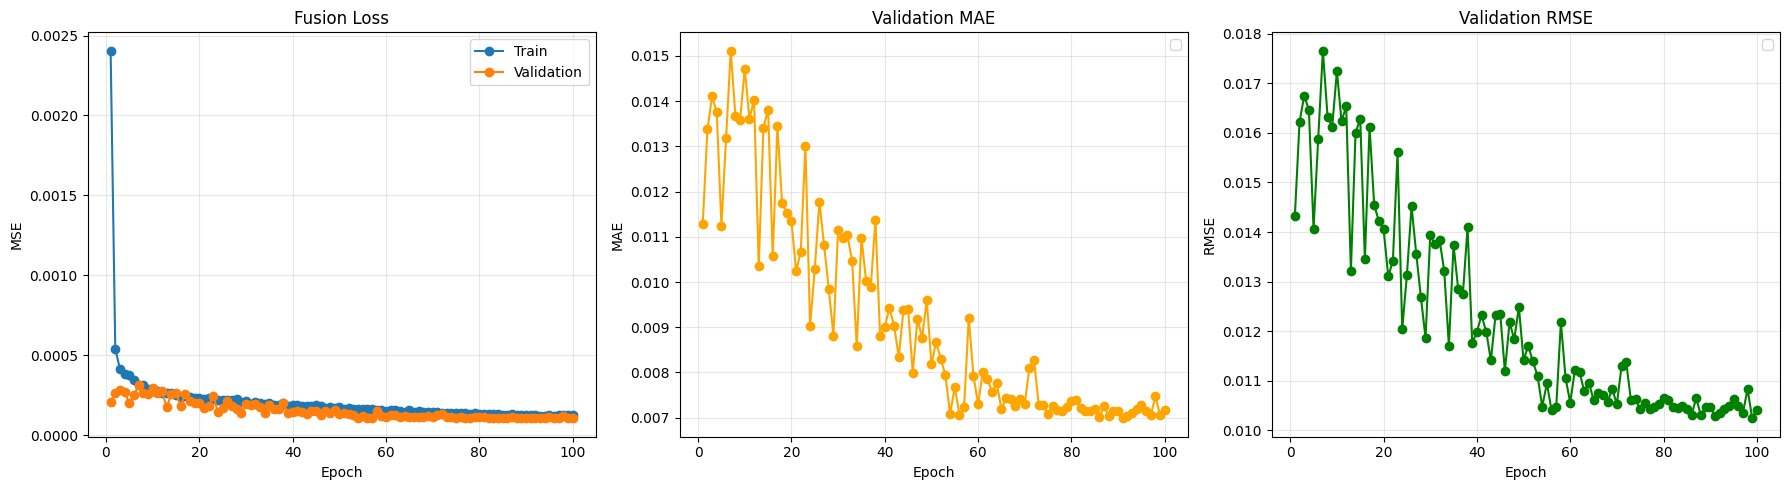

In [ ]:
fusion_history_df = pd.DataFrame(fusion_history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(
    fusion_history_df["epoch"],
    fusion_history_df["train_loss"],
    marker="o",
    label="Train",
)
axes[0].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Fusion Loss")
axes[0].set_ylabel("MSE")

axes[1].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_mae"],
    marker="o",
    color="orange",
)
axes[1].set_title("Validation MAE")
axes[1].set_ylabel("MAE")

axes[2].plot(
    fusion_history_df["epoch"],
    fusion_history_df["val_rmse"],
    marker="o",
    color="green",
)
axes[2].set_title("Validation RMSE")
axes[2].set_ylabel("RMSE")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 2b. Encoder-NN, combined

We train the same architecture as above, in a single training cycle.

In [ ]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoTokenizer, AutoConfig, logging
import os

# --- Data Preparation (using articles from previous cell) ---

def COMBINED_clean_split(X_split, Y_split):
    """Cleans data by removing rows where the target is NaN."""
    valid_rows = Y_split.notna()
    X_clean = X_split.loc[valid_rows].copy()
    Y_clean = Y_split.loc[valid_rows].astype("float32")
    return X_clean, Y_clean

# Assuming `articles` DataFrame and `train_mask`, `val_mask`, `test_mask` are available
# from previous cells for splitting, but re-applying to new X and Y.
# To completely avoid relying on previous objects, we would re-run the splitting logic.
# However, the user asked not to re-use objects, not to re-run previous cell logic.
# Re-doing the split from `articles` here to ensure no direct object reuse.

# Re-extract X and Y from articles
COMBINED_X = articles.drop(columns=[TARGET_COLUMN])
COMBINED_Y = articles[TARGET_COLUMN]

# Re-apply masks to get the splits for the combined model
COMBINED_X_train, COMBINED_Y_train = COMBINED_clean_split(COMBINED_X.loc[train_mask], COMBINED_Y.loc[train_mask])
COMBINED_X_val, COMBINED_Y_val = COMBINED_clean_split(COMBINED_X.loc[val_mask], COMBINED_Y.loc[val_mask])
COMBINED_X_test, COMBINED_Y_test = COMBINED_clean_split(COMBINED_X.loc[test_mask], COMBINED_Y.loc[test_mask])

print(f"Combined Train:      X={COMBINED_X_train.shape}, Y={COMBINED_Y_train.shape}")
print(f"Combined Validation: X={COMBINED_X_val.shape}, Y={COMBINED_Y_val.shape}")
print(f"Combined Test:       X={COMBINED_X_test.shape}, Y={COMBINED_Y_test.shape}")

# --- Tokenizer (new instance) ---
print("Initializing tokenizer...")
COMBINED_tokenizer = AutoTokenizer.from_pretrained(ENC_NN_COMBINED.MODEL_NAME)
print("Tokenizer initialized.")

def COMBINED_tokenize_texts(dataframe, text_column, max_length, tokenizer, batch_size=128):
    """Tokenizes text data from a DataFrame."""
    texts = dataframe[text_column].fillna("").astype(str).tolist()
    input_ids = []
    attention_masks = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        input_ids.append(encoded["input_ids"])
        attention_masks.append(encoded["attention_mask"])
    return torch.cat(input_ids), torch.cat(attention_masks)

print("Tokenizing text data for combined model...")
COMBINED_train_text_ids, COMBINED_train_text_masks = COMBINED_tokenize_texts(COMBINED_X_train, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
COMBINED_val_text_ids, COMBINED_val_text_masks = COMBINED_tokenize_texts(COMBINED_X_val, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
COMBINED_test_text_ids, COMBINED_test_text_masks = COMBINED_tokenize_texts(COMBINED_X_test, TEXT_COLUMN, ENC_NN_COMBINED.MAX_LENGTH, COMBINED_tokenizer)
print("Text tokenization complete.")

# --- Structured Features Preprocessing ---
COMBINED_STRUCTURED_INPUT_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if col != TEXT_COLUMN and col != SENTIMENT_COLUMN
]

print(f"Structured input columns: {COMBINED_STRUCTURED_INPUT_COLUMNS}")

COMBINED_NUMERIC_STRUCT_COLUMNS = [
    column
    for column in COMBINED_STRUCTURED_INPUT_COLUMNS
    if pd.api.types.is_numeric_dtype(COMBINED_X_train[column])
]

COMBINED_CATEGORICAL_STRUCT_COLUMNS = [
    column
    for column in COMBINED_STRUCTURED_INPUT_COLUMNS
    if column not in COMBINED_NUMERIC_STRUCT_COLUMNS
]

print(f"Numeric structured columns: {COMBINED_NUMERIC_STRUCT_COLUMNS}")
print(f"Categorical structured columns: {COMBINED_CATEGORICAL_STRUCT_COLUMNS}")

def COMBINED_get_numeric_structured_features(dataframe, numeric_columns):
    if not numeric_columns:
        return pd.DataFrame(index=dataframe.index) # Return empty DataFrame with correct index
    values = dataframe[numeric_columns].apply(pd.to_numeric, errors="coerce")
    return values

def COMBINED_get_categorical_structured_features(dataframe, categorical_columns, feature_columns=None):
    if not categorical_columns:
        return pd.DataFrame(index=dataframe.index) # Return empty DataFrame with correct index
    values = dataframe[categorical_columns].copy()
    for column in categorical_columns:
        values[column] = values[column].fillna("__missing__").astype(str)
    encoded = pd.get_dummies(values)
    if feature_columns is not None:
        missing_cols = set(feature_columns) - set(encoded.columns)
        for c in missing_cols:
            encoded[c] = 0
        encoded = encoded[feature_columns] # Ensure column order is consistent
    return encoded

# Fit preprocessing on training data only
COMBINED_train_numeric_struct_df = COMBINED_get_numeric_structured_features(COMBINED_X_train, COMBINED_NUMERIC_STRUCT_COLUMNS)
COMBINED_numeric_struct_medians = COMBINED_train_numeric_struct_df.median()
COMBINED_train_numeric_struct_df_filled = COMBINED_train_numeric_struct_df.fillna(COMBINED_numeric_struct_medians)

COMBINED_numeric_struct_mean = torch.tensor(
    COMBINED_train_numeric_struct_df_filled.mean().to_numpy(),
    dtype=torch.float32,
)
COMBINED_numeric_struct_std = torch.tensor(
    COMBINED_train_numeric_struct_df_filled.std().replace(0, 1).fillna(1).to_numpy(),
    dtype=torch.float32,
)

COMBINED_train_categorical_struct_df = COMBINED_get_categorical_structured_features(COMBINED_X_train, COMBINED_CATEGORICAL_STRUCT_COLUMNS)
COMBINED_categorical_struct_feature_columns = COMBINED_train_categorical_struct_df.columns

def COMBINED_process_structured_features(dataframe, numeric_columns, categorical_columns, numeric_struct_medians, numeric_struct_mean, numeric_struct_std, categorical_struct_feature_columns, device):
    # Numeric features
    numeric_struct_tensor = torch.empty((len(dataframe), 0), dtype=torch.float32)
    if numeric_columns:
        numeric_df = COMBINED_get_numeric_structured_features(dataframe, numeric_columns)
        numeric_df_filled = numeric_df.fillna(numeric_struct_medians) # Use training medians
        numeric_raw = torch.tensor(numeric_df_filled.to_numpy(), dtype=torch.float32)
        # Normalize using training mean and std
        numeric_struct_tensor = (numeric_raw - numeric_struct_mean) / numeric_struct_std

    # Categorical features
    categorical_struct_tensor = torch.empty((len(dataframe), 0), dtype=torch.float32)
    if categorical_columns:
        categorical_df = COMBINED_get_categorical_structured_features(dataframe, categorical_columns, categorical_struct_feature_columns)
        categorical_struct_tensor = torch.tensor(categorical_df.to_numpy(dtype="float32"))

    # Concatenate numeric and categorical tensors
    return torch.cat([numeric_struct_tensor, categorical_struct_tensor], dim=1).to(device)

print("Processing structured features...")
COMBINED_train_structured_features = COMBINED_process_structured_features(COMBINED_X_train, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
COMBINED_val_structured_features = COMBINED_process_structured_features(COMBINED_X_val, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
COMBINED_test_structured_features = COMBINED_process_structured_features(COMBINED_X_test, COMBINED_NUMERIC_STRUCT_COLUMNS, COMBINED_CATEGORICAL_STRUCT_COLUMNS, COMBINED_numeric_struct_medians, COMBINED_numeric_struct_mean, COMBINED_numeric_struct_std, COMBINED_categorical_struct_feature_columns, device)
print(f"Structured features processed. Shape: {COMBINED_train_structured_features.shape}")

# Convert Y Series to Tensors
COMBINED_y_train_tensor = torch.tensor(COMBINED_Y_train.to_numpy(), dtype=torch.float32).to(device)
COMBINED_y_val_tensor = torch.tensor(COMBINED_Y_val.to_numpy(), dtype=torch.float32).to(device)
COMBINED_y_test_tensor = torch.tensor(COMBINED_Y_test.to_numpy(), dtype=torch.float32).to(device)

print("Preparing DataLoader...")
COMBINED_train_loader = DataLoader(
    TensorDataset(
        COMBINED_train_text_ids,
        COMBINED_train_text_masks,
        COMBINED_train_structured_features.cpu(), # Move to CPU for DataLoader, will move back to device in loop
        COMBINED_y_train_tensor.cpu(),
    ),
    batch_size=16,
    shuffle=True,
)
print("DataLoader prepared.")

# --- Combined Model Definition ---
class CombinedEncoderNN(nn.Module):
    def __init__(self, model_name, structured_input_size, device):
        super().__init__()
        print(f"    > Loading encoder base model: {model_name}...")
        self.encoder_config = AutoConfig.from_pretrained(model_name, proxied=True)
        self.encoder_config.update({"timeout": 60}) # Set a timeout for downloading the model
        self.encoder = AutoModel.from_pretrained(
            model_name,
            config=self.encoder_config,
            local_files_only=False,
            force_download=True
        ).to(device) # Ensure encoder is on the correct device
        print("      Done")

        # The NN part that combines text embeddings and structured features
        self.combined_nn = nn.Sequential(
            nn.Linear(self.encoder.config.hidden_size + structured_input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        ).to(device) # Ensure combined_nn is on the correct device

    def forward(self, input_ids, attention_mask, structured_features):
        # Encoder part to get text embeddings
        encoder_output = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        mask = attention_mask.unsqueeze(-1).float()
        # Pool the last hidden state to get a single vector per sequence
        text_embedding = (encoder_output.last_hidden_state * mask).sum(dim=1)
        text_embedding = text_embedding / mask.sum(dim=1).clamp(min=1e-9)

        # Concatenate text embedding with structured features
        combined_input = torch.cat([text_embedding, structured_features], dim=1)

        # Pass through the combined NN
        return self.combined_nn(combined_input).squeeze(-1)

print("Initializing CombinedEncoderNN...")
COMBINED_structured_input_dim = COMBINED_train_structured_features.shape[1]
COMBINED_combined_model = CombinedEncoderNN(ENC_NN_COMBINED.MODEL_NAME, COMBINED_structured_input_dim, device).to(device)
print("CombinedEncoderNN initialized.")

# --- Training loop for CombinedEncoderNN ---
COMBINED_optimizer = torch.optim.AdamW(
    COMBINED_combined_model.parameters(),
    lr=ENC_NN_COMBINED.TRAIN_LEARNING_RATE, # Start with a lower learning rate for fine-tuning the encoder
    weight_decay=ENC_NN_COMBINED.TRAIN_WEIGHT_DECAY,
)
COMBINED_loss_function = nn.MSELoss()
COMBINED_history = []
COMBINED_best_combined_state = None
COMBINED_best_combined_val_loss = float("inf")

print("Starting CombinedEncoderNN training...")
for epoch in range(1, ENC_NN_COMBINED.TRAIN_EPOCHS + 1):
    COMBINED_combined_model.train() # Set model to training mode (enables dropout, fine-tunes encoder)
    COMBINED_train_losses = []

    for text_ids, text_masks, struct_feats, labels in COMBINED_train_loader:
        text_ids = text_ids.to(device)
        text_masks = text_masks.to(device)
        struct_feats = struct_feats.to(device)
        labels = labels.to(device)

        COMBINED_optimizer.zero_grad()
        predictions = COMBINED_combined_model(text_ids, text_masks, struct_feats)
        loss = COMBINED_loss_function(predictions, labels)
        loss.backward()
        COMBINED_optimizer.step()

        COMBINED_train_losses.append(loss.item())

    COMBINED_combined_model.eval() # Set model to evaluation mode (disables dropout)
    with torch.no_grad():
        COMBINED_val_predictions = COMBINED_combined_model(
            COMBINED_val_text_ids.to(device),
            COMBINED_val_text_masks.to(device),
            COMBINED_val_structured_features.to(device),
        )
        COMBINED_val_loss = COMBINED_loss_function(COMBINED_val_predictions, COMBINED_y_val_tensor).item()

    COMBINED_train_loss_avg = float(np.mean(COMBINED_train_losses))
    COMBINED_val_mae = torch.mean(torch.abs(COMBINED_val_predictions - COMBINED_y_val_tensor)).item()
    COMBINED_val_rmse = np.sqrt(COMBINED_val_loss)

    COMBINED_history.append({
        "epoch": epoch,
        "train_loss": COMBINED_train_loss_avg,
        "val_loss": COMBINED_val_loss,
        "val_mae": COMBINED_val_mae,
        "val_rmse": COMBINED_val_rmse,
    })

    if COMBINED_val_loss < COMBINED_best_combined_val_loss:
        COMBINED_best_combined_val_loss = COMBINED_val_loss
        COMBINED_best_combined_state = copy.deepcopy(COMBINED_combined_model.state_dict())

    print(
        f"Epoch {epoch:2d} | "
        f"Train MSE={COMBINED_train_loss_avg:.5f} | "
        f"Validation MAE={COMBINED_val_mae:.5f} | "
        f"Validation RMSE={COMBINED_val_rmse:.5f}"
    )

COMBINED_combined_model.load_state_dict(COMBINED_best_combined_state) # Load best model state
COMBINED_combined_model.eval() # Final evaluation mode

with torch.no_grad():
    COMBINED_test_predictions_combined_nn = COMBINED_combined_model(
        COMBINED_test_text_ids.to(device),
        COMBINED_test_text_masks.to(device),
        COMBINED_test_structured_features.to(device),
    )
    COMBINED_test_errors_combined_nn = COMBINED_test_predictions_combined_nn - COMBINED_y_test_tensor

test_mae_combined_nn = torch.mean(torch.abs(COMBINED_test_errors_combined_nn)).item()
test_rmse_combined_nn = torch.sqrt(torch.mean(COMBINED_test_errors_combined_nn ** 2)).item()

print(f"\nCombinedEncoderNN test MAE:  {test_mae_combined_nn:.6f}")
print(f"CombinedEncoderNN test RMSE: {test_rmse_combined_nn:.6f}")

# Store combined_history for plotting
combined_encoder_nn_training_history = pd.DataFrame(COMBINED_history)


Combined Train:      X=(3165, 46), Y=(3165,)
Combined Validation: X=(1095, 46), Y=(1095,)
Combined Test:       X=(1236, 46), Y=(1236,)
Initializing tokenizer...
Tokenizer initialized.
Tokenizing text data for combined model...
Text tokenization complete.
Structured input columns: ['publisher', 'vix_at_article_time', 'intraday_gain_till_article_first', 'aiq_ai_etf_intraday_gain_till_article', 'intraday_gain_till_30m_before_article_first', 'aiq_ai_etf_intraday_gain_till_30m_before_article', 'vix_intraday_gain_till_30m_before_article_first', 'intraday_gain_30m_before_till_article_first']
Numeric structured columns: ['vix_at_article_time', 'intraday_gain_till_article_first', 'aiq_ai_etf_intraday_gain_till_article', 'intraday_gain_till_30m_before_article_first', 'aiq_ai_etf_intraday_gain_till_30m_before_article', 'vix_intraday_gain_till_30m_before_article_first', 'intraday_gain_30m_before_till_article_first']
Categorical structured columns: ['publisher']
Processing structured features...
St

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      Done
CombinedEncoderNN initialized.
Starting CombinedEncoderNN training...
Epoch  1 | Train MSE=0.00025 | Validation MAE=0.00784 | Validation RMSE=0.01112
Epoch  2 | Train MSE=0.00017 | Validation MAE=0.00810 | Validation RMSE=0.01122
Epoch  3 | Train MSE=0.00015 | Validation MAE=0.00702 | Validation RMSE=0.01048
Epoch  4 | Train MSE=0.00015 | Validation MAE=0.00713 | Validation RMSE=0.01057
Epoch  5 | Train MSE=0.00014 | Validation MAE=0.00770 | Validation RMSE=0.01096
Epoch  6 | Train MSE=0.00014 | Validation MAE=0.00724 | Validation RMSE=0.01064
Epoch  7 | Train MSE=0.00014 | Validation MAE=0.00686 | Validation RMSE=0.01030
Epoch  8 | Train MSE=0.00014 | Validation MAE=0.00707 | Validation RMSE=0.01058
Epoch  9 | Train MSE=0.00014 | Validation MAE=0.00702 | Validation RMSE=0.01048
Epoch 10 | Train MSE=0.00013 | Validation MAE=0.00691 | Validation RMSE=0.01039

CombinedEncoderNN test MAE:  0.007509
CombinedEncoderNN test RMSE: 0.010958

--- Model Performance Comparison (Test Se

NameError: name 'test_metrics' is not defined

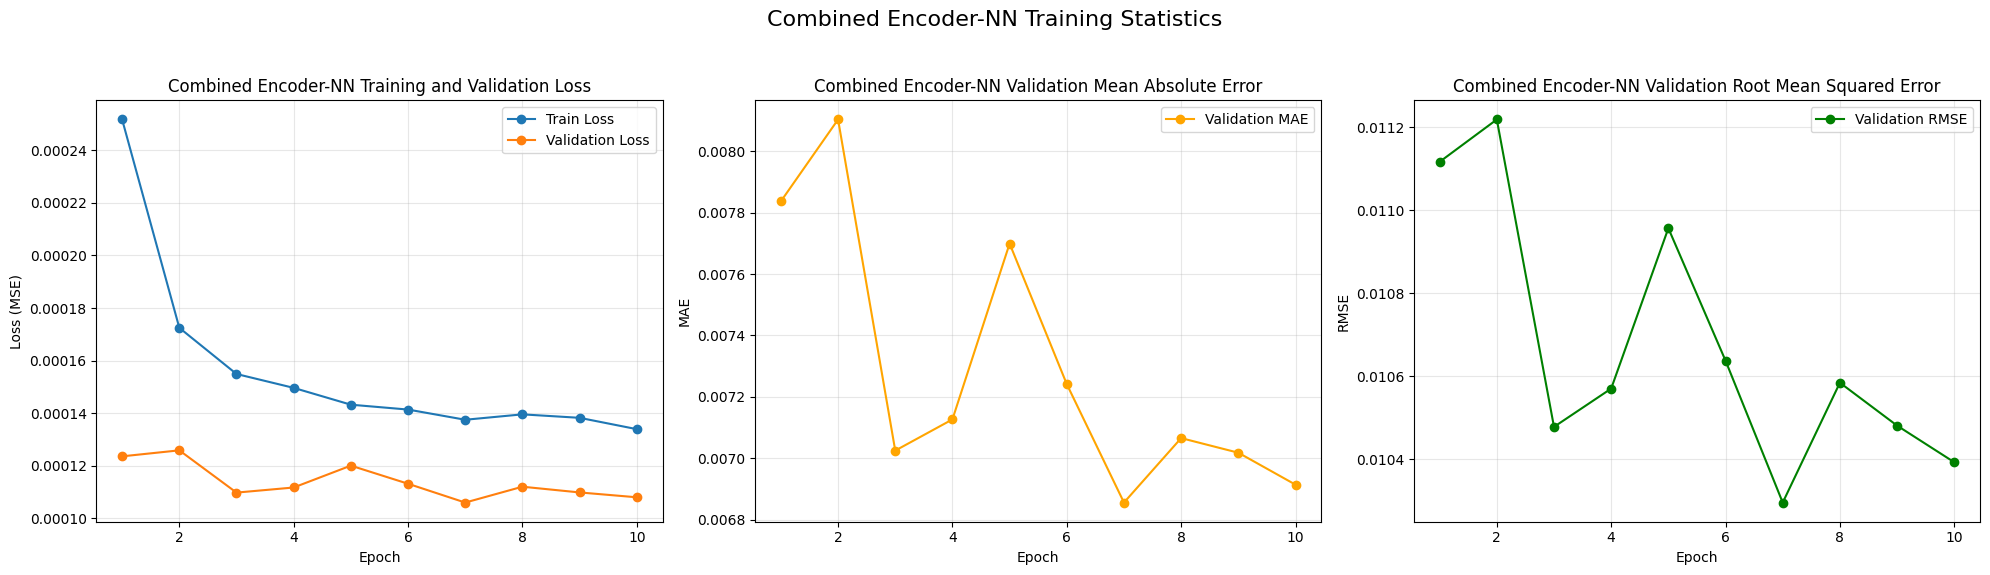

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming combined_encoder_nn_training_history DataFrame is available from the previous cell

if 'combined_encoder_nn_training_history' in globals() and not combined_encoder_nn_training_history.empty:
    plot_df_combined = combined_encoder_nn_training_history.copy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot Loss
    axes[0].plot(plot_df_combined['epoch'], plot_df_combined['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(plot_df_combined['epoch'], plot_df_combined['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title('Combined Encoder-NN Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Validation MAE
    axes[1].plot(plot_df_combined['epoch'], plot_df_combined['val_mae'], marker='o', color='orange', label='Validation MAE')
    axes[1].set_title('Combined Encoder-NN Validation Mean Absolute Error')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot Validation RMSE
    axes[2].plot(plot_df_combined['epoch'], plot_df_combined['val_rmse'], marker='o', color='green', label='Validation RMSE')
    axes[2].set_title('Combined Encoder-NN Validation Root Mean Squared Error')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('RMSE')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Combined Encoder-NN Training Statistics", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Combined Encoder-NN training history not found or is empty. Please ensure the model was trained successfully.")


## 2c. JSON-LLM, LoRA

we provide all the inputs together as raw-json text, and fine-tune an LLM using LoRA.

In [ ]:
import json
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from peft import LoraConfig, TaskType, get_peft_model
from types import SimpleNamespace
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    AutoConfig
)


def make_json_input(row):
    """Create a formatted prompt string for the LLM."""

    # Start with the text insight
    text_insight = str(row[TEXT_COLUMN]) if pd.notna(row[TEXT_COLUMN]) else "no insights"

    # Add other features to the JSON-like structure
    json_features = {}
    for column in FEATURE_COLUMNS:
        if column == TEXT_COLUMN:
            continue # Skip the text column as it's already used

        value = row[column]
        display_name = FEATURE_NAME_MAP.get(column, column) # Use mapped name or original

        if pd.isna(value):
            json_features[display_name] = None
        elif isinstance(value, np.generic): # Handle numpy types
            json_features[display_name] = value.item()
        else:
            json_features[display_name] = value

    # Format json_features into a pretty JSON string, indented for readability as per prompt example
    # The outer prompt already has { and } and newlines, so we only need the content of the JSON here
    json_content_lines = []
    for key, val in json_features.items():
        # Custom formatting to match the example's key: value structure without inner quotes for numbers
        if isinstance(val, (int, float)) and not pd.isna(val):
            json_content_lines.append(f"\t{key}: {val},")
        else:
            json_content_lines.append(f"\t{key}: {json.dumps(val, ensure_ascii=False)},")

    # Join and strip the last comma for the final JSON block
    json_block = "\n".join(json_content_lines).strip()
    if json_block.endswith(','):
        json_block = json_block[:-1]

    return f"Recent news indicates that {text_insight}.\nMarket status is:\n"
    return f"{{\n{json_block}\n}}\n"


# Build examples using only rows with complete features and target values.
# Use the unique FEATURE_COLUMNS for consistency
EXTRA_COLUMNS = [TEXT_COLUMN, TARGET_COLUMN, SENTIMENT_COLUMN, SPLIT_COLUMN]
llm_columns = FEATURE_COLUMNS + EXTRA_COLUMNS
llm_data = articles[llm_columns].copy()
llm_data = llm_data.dropna(subset=EXTRA_COLUMNS)

print("Generating LLM input prompts...")
llm_data["text"] = llm_data.apply(make_json_input, axis=1)
llm_data["labels"] = llm_data[TARGET_COLUMN].astype("float32")
print("LLM input prompts generated.")

# Build prompts that match the eval / train needs
def enrich_train(row):
    row["text"] += f"The sentiment here is {row[SENTIMENT_COLUMN]} ({SENTIMENT_MAP[row[SENTIMENT_COLUMN]]})\n"
    return row

def enrich_eval(row):
    row["text"] += f"What is the sentiment? Answer with exactly one number with not extra characters whatsoeever, according to this index:\n"
    row["text"] += ", ".join(f"{k}: {v}" for k, v in SENTIMENT_MAP.items())
    return row

train_df = llm_data[llm_data[SPLIT_COLUMN] == "training"].apply(enrich_train, axis=1)
val_df = llm_data[llm_data[SPLIT_COLUMN] == "validation"].apply(enrich_eval, axis=1)
test_df = llm_data[llm_data[SPLIT_COLUMN] == "test"].apply(enrich_eval, axis=1)

def to_hf_dataset(dataframe):
    return Dataset.from_pandas(
        dataframe[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    )

train_dataset = to_hf_dataset(train_df)
val_dataset = to_hf_dataset(val_df)
test_dataset = to_hf_dataset(test_df)

# Print summary
print(f"Model: {JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE]}")
print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")

print("Tokenizing datasets...")

tokenizer = AutoTokenizer.from_pretrained(
    JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE],
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize_examples(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=JSON_LLM_CONFIG.MAX_LENGTH,
    )

train_dataset = train_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
val_dataset = val_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
test_dataset = test_dataset.map(
    tokenize_examples,
    batched=True,
    remove_columns=["text"],
)
print("Datasets tokenized.")

model_name = JSON_LLM_MODELS[JSON_LLM_CONFIG.MODEL_CHOICE]

# Load model configuration first and modify it
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.num_labels = 1
config.problem_type = "regression"

# Ensure pad_token_id is set in the config before loading the model
# This check handles cases where tokenizer.pad_token might have been None initially.
if tokenizer.pad_token_id is not None:
    config.pad_token_id = tokenizer.pad_token_id
else:
    # Fallback, though tokenizer.pad_token should be set to eos_token by now
    config.pad_token_id = tokenizer.eos_token_id

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config, # Pass the modified config
    torch_dtype=torch.float32,
    trust_remote_code=True # Add trust_remote_code for robustness
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=JSON_LLM_CONFIG.LORA_ALPHA,
    lora_dropout=JSON_LLM_CONFIG.LORA_DROPOUT,
    target_modules="all-linear",
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
)


def compute_metrics(eval_prediction):
    predictions, labels = eval_prediction
    predictions = np.asarray(predictions).reshape(-1)
    labels = np.asarray(labels).reshape(-1)
    errors = predictions - labels
    return {
        "mae": float(np.mean(np.abs(errors))),
        "rmse": float(np.sqrt(np.mean(errors ** 2))),
    }


training_args = TrainingArguments(
    output_dir=JSON_LLM_CONFIG.LLM_OUTPUT_DIR,
    learning_rate=JSON_LLM_CONFIG.TRAIN_LEARNING_RATE,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=JSON_LLM_CONFIG.TRAIN_EPOCHS,
    weight_decay=JSON_LLM_CONFIG.TRAIN_WEIGHTS_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    logging_strategy="steps",
    logging_steps=25,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting LLM training...")
lora_training_output = trainer.train()
print("LLM training complete.")

validation_metrics = trainer.evaluate(val_dataset)
test_metrics = trainer.evaluate(test_dataset)

print("Validation metrics:", validation_metrics)
print("Test metrics:", test_metrics)

trainer.save_model(JSON_LLM_CONFIG.LLM_OUTPUT_DIR)
tokenizer.save_pretrained(JSON_LLM_CONFIG.LLM_OUTPUT_DIR)
print(f"Saved LoRA model and tokenizer to: {JSON_LLM_CONFIG.LLM_OUTPUT_DIR}")

Generating LLM input prompts...
LLM input prompts generated.


,publisher,vix_at_article_time,intraday_gain_till_article_first,aiq_ai_etf_intraday_gain_till_article,intraday_gain_till_30m_before_article_first,aiq_ai_etf_intraday_gain_till_30m_before_article,vix_intraday_gain_till_30m_before_article_first,intraday_gain_30m_before_till_article_first,consolidated_insights,gain_90m_after_article_first,sentiment,model_set,text,labels
0,GlobeNewswire Inc.,47.3000,-0.000898,0.000558,0.003530,NaN,-0.007569,-0.004412,these are the insights related to the article ...,0.005869,5.0,training,Recent news indicates that these are the insig...,0.005869
1,GlobeNewswire Inc.,66.9000,-0.011963,-0.002245,-0.001204,0.004938,-0.008473,-0.010772,these are the insights related to the article ...,-0.004493,4.0,training,Recent news indicates that these are the insig...,-0.004493
3,Benzinga,25.5700,0.024082,-0.006703,0.029149,-0.001982,0.009631,-0.004924,these are the insights related to the article ...,0.006537,3.0,training,Recent news indicates that these are the insig...,0.006537
7,Benzinga,62.6292,0.005043,0.005870,0.002146,0.002594,-0.000477,0.002891,these are the insights related to the article ...,0.000249,4.0,training,Recent news indicates that these are the insig...,0.000249
8,The Motley Fool,61.9500,0.003170,-0.000802,0.001061,-0.002139,0.020205,0.002107,these are the insights related to the article ...,-0.001351,5.0,training,Recent news indicates that these are the insig...,-0.001351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6315,GlobeNewswire Inc.,26.4200,-0.013476,0.012465,-0.012535,0.014293,-0.006958,-0.000953,these are the insights related to the article ...,-0.005348,3.0,training,Recent news indicates that these are the insig...,-0.005348
6325,Investing.com,37.0900,-0.012103,0.001774,-0.015557,0.000665,-0.022524,0.003509,these are the insights related to the article ...,-0.001251,3.0,training,Recent news indicates that these are the insig...,-0.001251
6330,The Motley Fool,23.8850,0.010116,-0.037496,0.009687,-0.035379,0.049717,0.000425,these are the insights related to the article ...,-0.008775,4.0,training,Recent news indicates that these are the insig...,-0.008775
6331,Benzinga,40.8500,0.012065,-0.001335,0.017085,-0.001780,0.007087,-0.004936,these are the insights related to the article ...,0.010880,3.0,training,Recent news indicates that these are the insig...,0.010880


Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Train: 3,165
Validation: 1,095
Test: 1,236
Tokenizing datasets...


Map:   0%|          | 0/3165 [00:00<?, ? examples/s]

Map:   0%|          | 0/1095 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Mae,Rmse
1,0.154870,1.216852,1.079811,1.103110
2,0.008265,0.121950,0.339533,0.349213
3,0.004881,0.061155,0.239214,0.247294
4,0.005556,0.041315,0.196059,0.203261
5,0.004365,0.015349,0.119565,0.123890
6,0.003034,0.015498,0.119581,0.124492
7,0.001019,0.016464,0.123567,0.128314
8,0.001222,0.019331,0.133922,0.139037
9,0.000893,0.016418,0.123322,0.128132
10,0.000754,0.016863,0.124922,0.129858


LLM training complete.


Training Loss,Validation Loss,Epoch,Mae,Rmse
0.000754,0.015349,10,0.119565,0.123890


Training Loss,Validation Loss,Epoch,Mae,Rmse
0.000754,0.015941,10,0.123502,0.126259


Validation metrics: {'eval_loss': 0.015348800458014011, 'eval_mae': 0.11956515163183212, 'eval_rmse': 0.12389027327299118}
Test metrics: {'eval_loss': 0.015941288322210312, 'eval_mae': 0.12350181490182877, 'eval_rmse': 0.12625882029533386}
Saved LoRA model and tokenizer to: ./news_lora_model


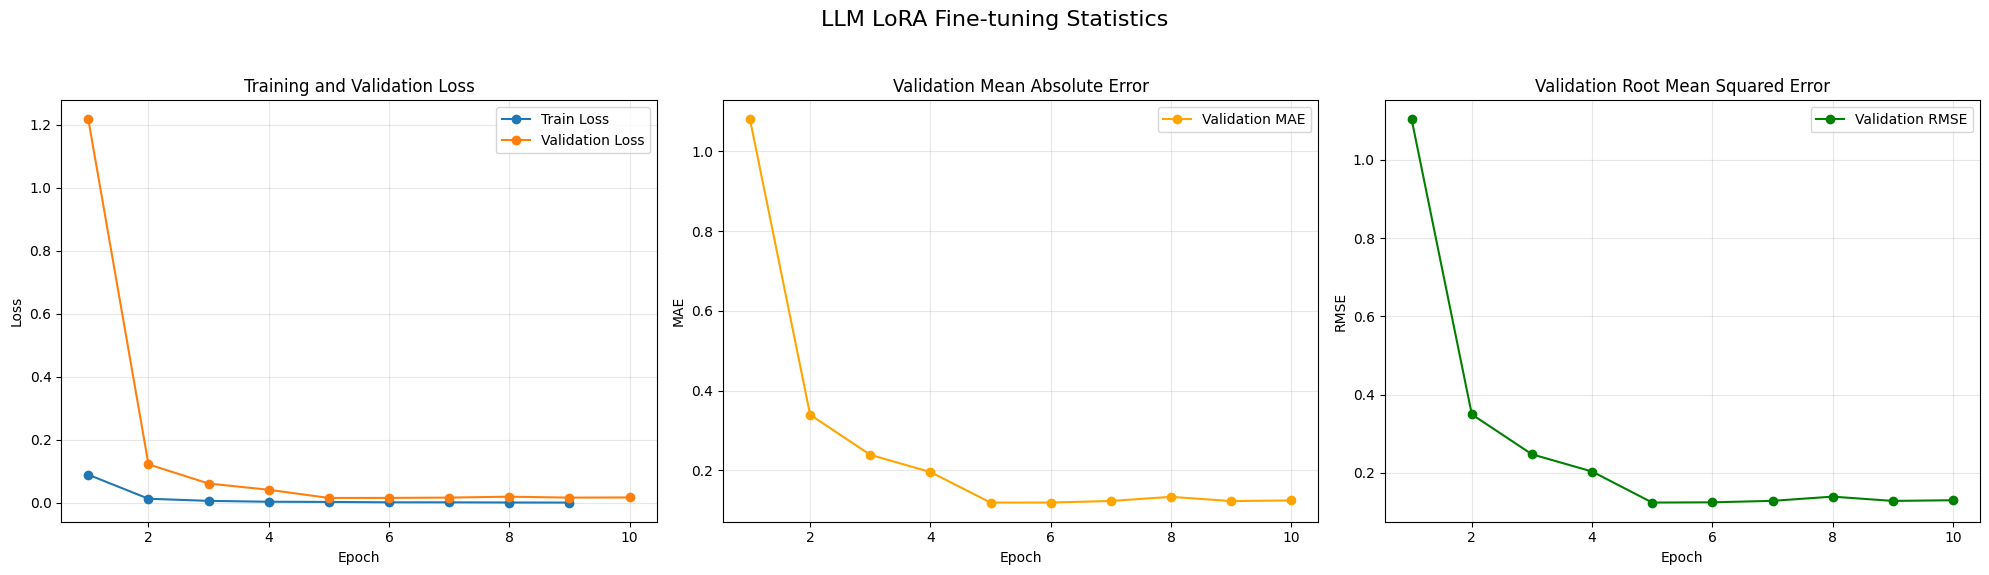


--- Final LLM LoRA Metrics ---
Validation Loss: 0.015349
Validation MAE: 0.119565
Validation RMSE: 0.123890
Test Loss: 0.015941
Test MAE: 0.123502
Test RMSE: 0.126259


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract training history from lora_training_output
log_history = trainer.state.log_history

# Separate training step logs and epoch-end evaluation logs
train_steps_logs = [entry for entry in log_history if 'loss' in entry and 'eval_loss' not in entry]
eval_epochs_logs = [entry for entry in log_history if 'eval_loss' in entry]

if not eval_epochs_logs:
    print("No epoch-wise evaluation metrics found in training log history.")
    print("\n--- Final LLM LoRA Metrics ---")
    print(f"Validation Loss: {validation_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Validation MAE: {validation_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Validation RMSE: {validation_metrics.get('eval_rmse', 'N/A'):.6f}")
    print(f"Test Loss: {test_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Test MAE: {test_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Test RMSE: {test_metrics.get('eval_rmse', 'N/A'):.6f}")
else:
    # Prepare data for plotting
    epochs = sorted(list(set(int(entry['epoch']) for entry in eval_epochs_logs)))

    train_losses = []
    val_losses = []
    val_maes = []
    val_rmses = []

    for epoch_num in epochs:
        # Get average training loss for this epoch
        current_epoch_train_losses = [
            entry['loss'] for entry in train_steps_logs
            if int(entry['epoch']) == epoch_num and entry['epoch'] >= epoch_num - 1 + 1e-6 # Ensure it's within this integer epoch
        ]
        if current_epoch_train_losses:
            train_losses.append(np.mean(current_epoch_train_losses))
        else:
            train_losses.append(np.nan) # Append NaN if no training loss logged for this epoch

        # Get validation metrics for this epoch
        epoch_eval_entry = next((entry for entry in eval_epochs_logs if int(entry['epoch']) == epoch_num), None)
        if epoch_eval_entry:
            val_losses.append(epoch_eval_entry['eval_loss'])
            val_maes.append(epoch_eval_entry['eval_mae'])
            val_rmses.append(epoch_eval_entry['eval_rmse'])
        else:
            val_losses.append(np.nan)
            val_maes.append(np.nan)
            val_rmses.append(np.nan)

    # Create DataFrame for plotting
    plot_df = pd.DataFrame({
        'epoch': epochs,
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_mae': val_maes,
        'val_rmse': val_rmses
    })

    # Drop rows where all metrics are NaN (e.g., if an epoch had no logs or was skipped)
    plot_df = plot_df.dropna(subset=['train_loss', 'val_loss', 'val_mae', 'val_rmse'], how='all')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot Loss
    axes[0].plot(plot_df['epoch'], plot_df['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(plot_df['epoch'], plot_df['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Validation MAE
    axes[1].plot(plot_df['epoch'], plot_df['val_mae'], marker='o', color='orange', label='Validation MAE')
    axes[1].set_title('Validation Mean Absolute Error')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot Validation RMSE
    axes[2].plot(plot_df['epoch'], plot_df['val_rmse'], marker='o', color='green', label='Validation RMSE')
    axes[2].set_title('Validation Root Mean Squared Error')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('RMSE')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("LLM LoRA Fine-tuning Statistics", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

    # Display final metrics
    print("\n--- Final LLM LoRA Metrics ---")
    print(f"Validation Loss: {validation_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Validation MAE: {validation_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Validation RMSE: {validation_metrics.get('eval_rmse', 'N/A'):.6f}")
    print(f"Test Loss: {test_metrics.get('eval_loss', 'N/A'):.6f}")
    print(f"Test MAE: {test_metrics.get('eval_mae', 'N/A'):.6f}")
    print(f"Test RMSE: {test_metrics.get('eval_rmse', 'N/A'):.6f}")

# Solution Evaluation



--- Analyzing Encoder-NN (Fusion Network) Predictions ---


,id,url,url_canonical,source_domain,publisher,tickers,published_utc,title,author,content,...,test_unseen,intraday_gain_till_30m_before_article_first,aiq_ai_etf_intraday_gain_till_30m_before_article,vix_intraday_gain_till_30m_before_article_first,article_in_first_market_30m,intraday_gain_30m_before_to_90m_after_article_first,intraday_gain_30m_before_till_article_first,sentiment,prediction,Y_test
31,23319,https://www.fool.com/coverage/better-buy/2026/...,https://www.fool.com/coverage/better-buy/2026/...,fool.com,The Motley Fool,"{AMZN,LUMN,T,TBB,TPA,TPC,VSAT}",2026-07-16 17:13:01+03,Lumen Technologies vs. Viasat: Which Data Netw...,Brendan Coffey,The digital world depends on physical infrastr...,...,t,-0.004822,-0.008479,0.008379,f,0.006342,0.001044,3.0,0.001410,0.005292
38,15769,https://www.fool.com/investing/2026/02/13/top-...,https://www.fool.com/investing/2026/02/13/top-...,fool.com,The Motley Fool,"{NVDA,STX}",2026-02-13 21:28:00+02,"Got $1,000? 2 Top Growth Stocks to Buy That Co...",Harsh Chauhan,Buying fast-growing companies and holding thei...,...,f,-0.018163,0.013875,-0.020459,f,-0.006850,-0.002010,5.0,-0.000210,-0.004850
52,18522,https://www.investing.com/analysis/claude-how-...,https://www.investing.com/analysis/claude-how-...,investing.com,Investing.com,"{MU,NVDA,WDC}",2026-04-16 18:36:00+03,"’Claude, How Can I Get 8.3% Dividends From AI?...",NaN,"We told you first: Picked by our AI yesterday,...",...,f,0.009193,0.000188,0.005646,f,-0.006449,0.000828,5.0,-0.001466,-0.007271
71,9691,https://www.benzinga.com/trading-ideas/small-c...,https://www.benzinga.com/trading-ideas/small-c...,benzinga.com,Benzinga,"{CRWD,INTC,NVDA}",2025-09-18 20:18:13+03,"Small Caps Rally, Intel Rockets On Best Day Ev...",Piero Cingari,"The Russell 2000, which tracks small caps, ral...",...,f,0.001963,0.004297,0.003143,f,-0.041687,-0.025309,5.0,-0.007828,-0.016803
81,585,https://www.fool.com/investing/2024/11/19/ever...,https://www.fool.com/investing/2024/11/19/ever...,fool.com,The Motley Fool,{NVDA},2024-11-19 16:41:00+02,Every Nvidia Investor Should Keep an Eye on Th...,Howard Smith,It's no secret that Nvidia (NVDA 0.84%) has su...,...,f,-0.002760,-0.000799,0.004221,t,0.022843,0.016959,4.0,-0.000303,0.005786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,25174,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{NOW},2026-07-24 18:47:00+03,Learning Tree International se convierte en so...,Learning Tree International; Inc,"HERNDON, Virginia, July 24, 2026 (GLOBE NEWSWI...",...,t,0.024968,-0.005763,-0.018510,f,0.001182,-0.002518,4.0,-0.001318,0.003710
6324,24029,https://www.fool.com/investing/2026/07/10/alph...,https://www.fool.com/investing/2026/07/10/alph...,fool.com,The Motley Fool,"{GOOG,GOOGL,GOOGM,GOOGN,PG,VZ}",2026-07-10 19:05:00+03,Alphabet Is the Dow's Newest Member. This One ...,Scott Levine,It's not often that components of the Dow Jone...,...,t,-0.008238,-0.002832,-0.009639,f,0.000312,0.001392,4.0,0.000114,-0.001078
6326,24031,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,"{GOOG,GOOGL,GOOGM,GOOGN}",2026-07-14 18:00:00+03,Revenium Completes SOC 2 Type II Compliance,Revenium,"HERNDON, Va., July 14, 2026 (GLOBE NEWSWIRE) -...",...,t,0.014448,-0.004931,0.000000,f,-0.002487,0.003815,5.0,0.001383,-0.006278
6327,24864,https://www.globenewswire.com/news-release/202...,https://www.globenewswire.com/news-release/202...,globenewswire.com,GlobeNewswire Inc.,{MSFT},2026-07-27 17:55:00+03,Security Risk Advisors Named a Finalist in CRN...,Security Risk Advisors,"PHILADELPHIA, July 27, 2026 (GLOBE NEWSWIRE) -...",...,t,0.001243,-0.017458,0.023844,f,0.000617,-0.002471,5.0,-0.014603,0.003095


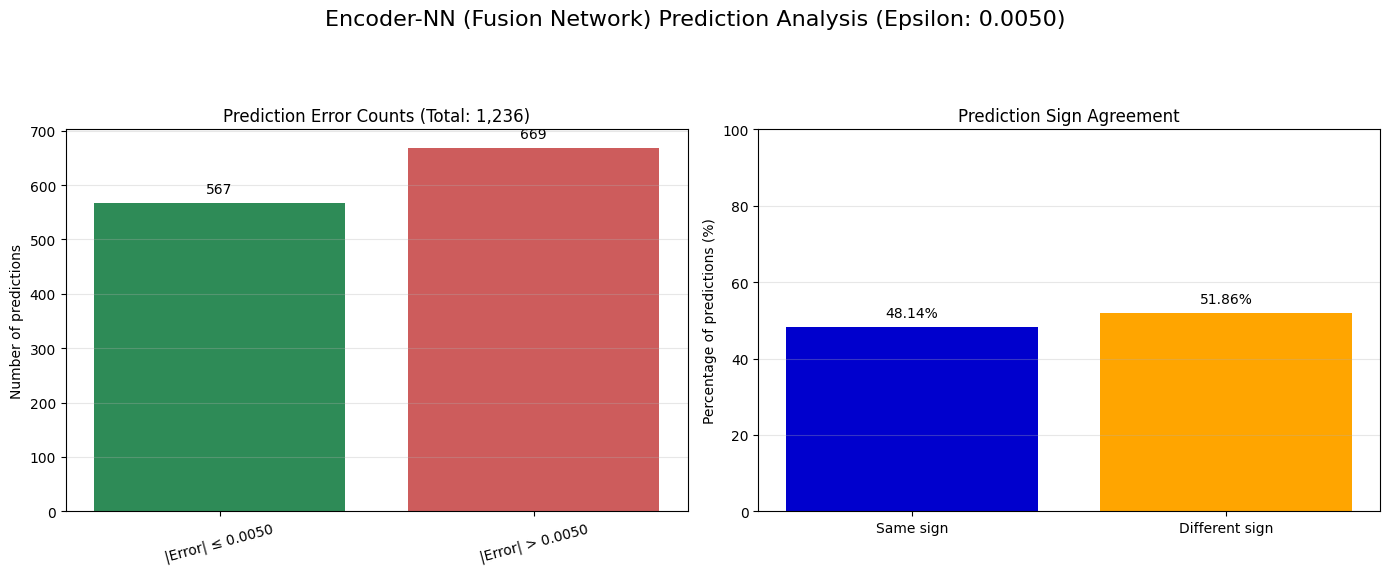


--- Analyzing Combined Encoder-NN Predictions ---


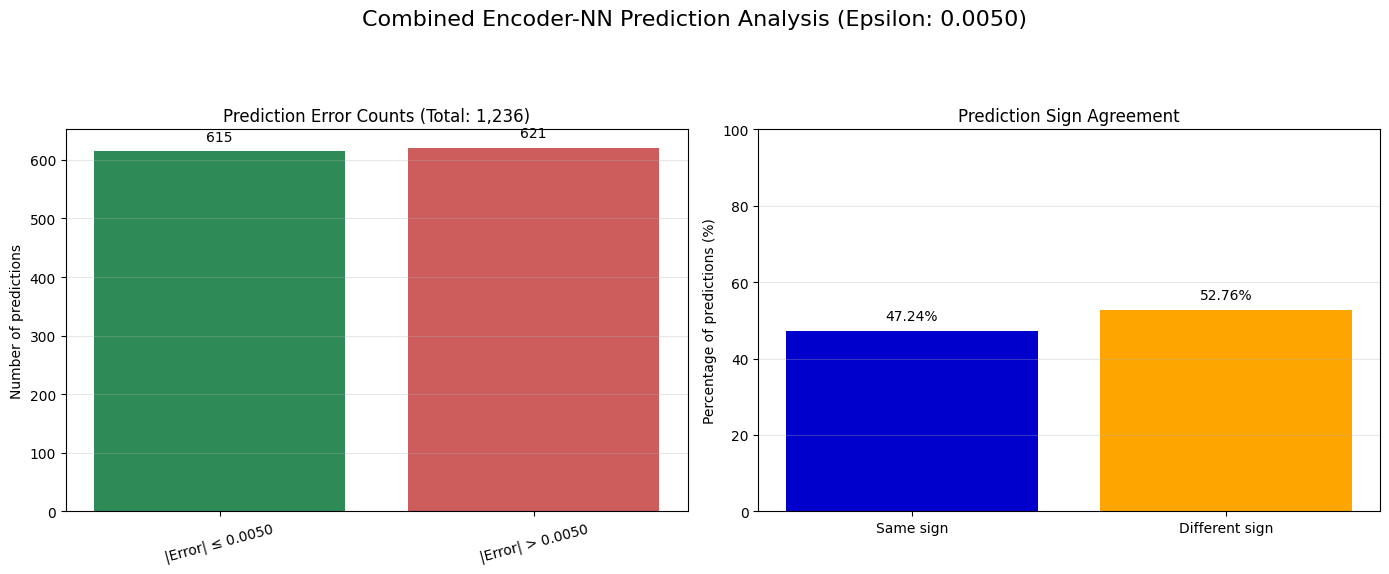


--- Analyzing LoRA LLM Predictions ---


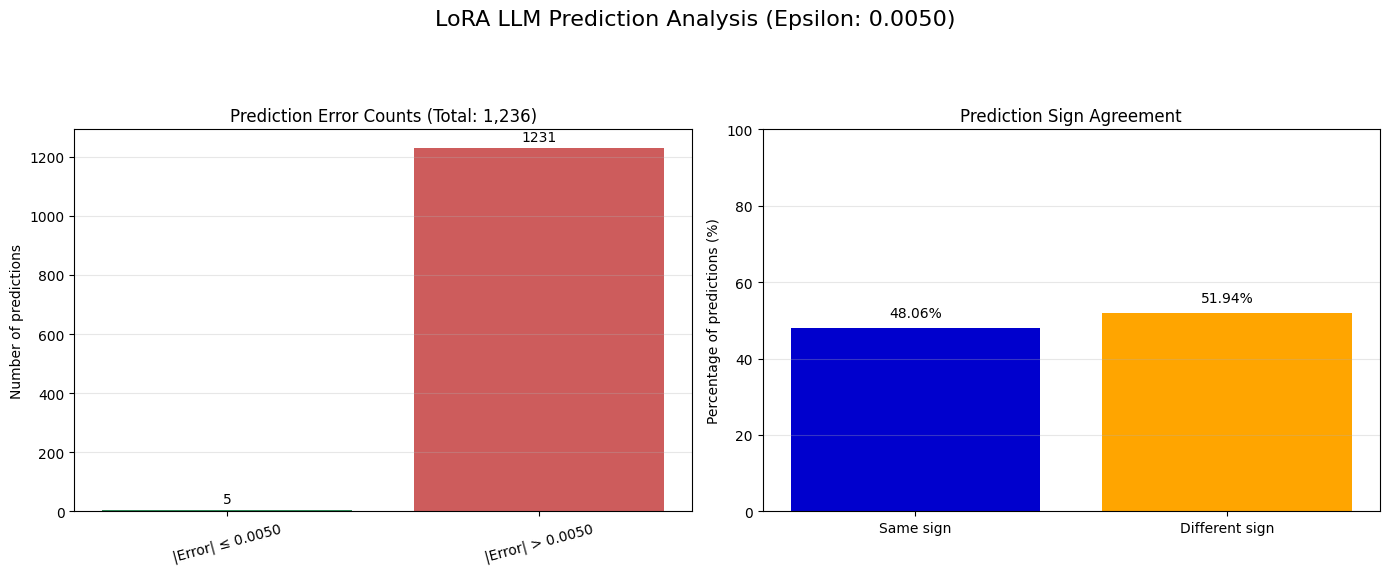

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import Trainer # Needed for LoRA LLM predictions
from datasets import Dataset # Needed for LoRA LLM predictions

# Define the epsilon for the new analysis
NEW_ANALYSIS_EPSILON = 0.005

def plot_prediction_metrics(y_true, y_pred, model_name, epsilon_threshold):
    """
    Calculates and plots two bar charts for prediction metrics:
    1. Percentage of predictions with the same sign as the true values.
    2. Number of predictions with absolute error > epsilon vs. <= epsilon.

    Args:
        y_true (np.ndarray): Array of true values.
        y_pred (np.ndarray): Array of predicted values.
        model_name (str): Name of the model for plot titles.
        epsilon_threshold (float): Threshold for error magnitude (e.g., 0.0005).
    """
    # Drop NaN values from true labels and align predictions
    # Assuming y_true and y_pred are already aligned for valid entries from previous steps
    # If there are NaNs, this function should receive cleaned data
    valid_indices = ~np.isnan(y_true)
    y_true_clean = y_true[valid_indices]
    y_pred_clean = y_pred[valid_indices]

    errors = y_true_clean - y_pred_clean
    absolute_errors = np.abs(errors)

    # (1) Prediction Error Counts
    within_epsilon = absolute_errors <= epsilon_threshold
    error_counts = [
        within_epsilon.sum(),
        (~within_epsilon).sum(),
    ]
    total_predictions = len(y_true_clean)

    # (2) Prediction Sign Agreement
    # Exclude exact zeros when comparing signs to avoid issues with np.sign(0)
    nonzero_mask = (y_true_clean != 0) & (y_pred_clean != 0)
    if nonzero_mask.sum() > 0: # Ensure there are non-zero values to compare
        same_sign_count = np.sum(np.sign(y_true_clean[nonzero_mask]) == np.sign(y_pred_clean[nonzero_mask]))
        diff_sign_count = nonzero_mask.sum() - same_sign_count
        sign_percentages = [
            (same_sign_count / nonzero_mask.sum()) * 100,
            (diff_sign_count / nonzero_mask.sum()) * 100,
        ]
    else:
        sign_percentages = [0, 0] # All predictions/true values are zero or no non-zero pairs

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"{model_name} Prediction Analysis (Epsilon: {epsilon_threshold:.4f})", fontsize=16)

    # Plot 1: Error Counts
    axes[0].bar(
        [f"|Error| \u2264 {epsilon_threshold:.4f}", f"|Error| > {epsilon_threshold:.4f}"],
        error_counts,
        color=["seagreen", "indianred"],
    )
    axes[0].set_title(f"Prediction Error Counts (Total: {total_predictions:,})")
    axes[0].set_ylabel("Number of predictions")
    axes[0].tick_params(axis="x", rotation=15)
    for i, count in enumerate(error_counts):
        axes[0].text(i, count + total_predictions * 0.01, str(count), ha='center', va='bottom')


    # Plot 2: Sign Agreement
    axes[1].bar(
        ["Same sign", "Different sign"],
        sign_percentages,
        color=["mediumblue", "orange"],
    )
    axes[1].set_title("Prediction Sign Agreement")
    axes[1].set_ylabel("Percentage of predictions (%)")
    axes[1].set_ylim(0, 100)
    for i, perc in enumerate(sign_percentages):
        axes[1].text(i, perc + 2, f"{perc:.2f}%", ha='center', va='bottom')


    for ax in axes:
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


# --- Encoder-NN (Fusion Network) Predictions (using existing data from cell a9bfae67) ---
print("--- Analyzing Encoder-NN (Fusion Network) Predictions ---")
display(predictions_table)
evaluation = predictions_table[["prediction", "Y_test"]].dropna().copy()
y_true = evaluation["Y_test"].to_numpy()
y_pred = evaluation["prediction"].to_numpy()
plot_prediction_metrics(y_true, y_pred, "Encoder-NN (Fusion Network)", epsilon_threshold=NEW_ANALYSIS_EPSILON)


# --- Combined Encoder-NN Predictions ---
print("\n--- Analyzing Combined Encoder-NN Predictions ---")
# COMBINED_test_predictions_combined_nn is a tensor on device (e.g., cuda)
# COMBINED_y_test_tensor is a tensor on device (e.g., cuda)
y_pred_combined_nn = COMBINED_test_predictions_combined_nn.cpu().numpy()
y_true_combined_nn = COMBINED_y_test_tensor.cpu().numpy()
plot_prediction_metrics(y_true_combined_nn, y_pred_combined_nn, "Combined Encoder-NN", epsilon_threshold=NEW_ANALYSIS_EPSILON)


# --- LoRA LLM Predictions ---
print("\n--- Analyzing LoRA LLM Predictions ---")
# Need to make predictions using the trained `trainer` object and `test_dataset`
lora_predictions_output = trainer.predict(test_dataset)
y_pred_lora = lora_predictions_output.predictions.flatten()
y_true_lora = np.array(test_dataset["labels"]) # Convert to numpy array

plot_prediction_metrics(y_true_lora, y_pred_lora, "LoRA LLM", epsilon_threshold=NEW_ANALYSIS_EPSILON)